In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_excel("../data/GrideH9_v1.xlsx")

# Basic overview
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

Shape of dataset: (4758, 46)

Column names:
 Index(['GRID_ID', 'occtype_IND', 'occtype_OTH', 'occtype_COM', 'occtype_RES',
       'bldgM', 'bldgS', 'bldgW', 'bldgC', 'num_story', 'sqft', 'found_ht',
       'val_struct', 'val_cont', 'age', 'num_story_med', 'num_story_sum',
       'sqft_med', 'sqft_sum', 'found_ht_med', 'found_ht_sum',
       'val_struct_med', 'val_struct_sum', 'val_cont_med', 'val_cont_sum',
       'age_med', 'age_sum', 'dist_reservoir', 'dist_coast', 'dist_htrack',
       'fld_zone', 'landcover', 'landuse', 'evac_degree', 'fld_pct',
       'rainfall', 'slope', 'elev', 'TCC_pct', 'VD_pct', 'wind_kph', 'VolCD',
       'VolCD_sum', 'VolVG', 'VolVG_sum', 'VolBoth_sum'],
      dtype='str')


===== X Clipping Summary =====
       feature   skew   upper  n_clipped  percent_clipped
0    num_story  30.97    1.21        952            20.01
1     found_ht   3.85    1.46        952            20.01
5        slope   2.58    3.50        476            10.00
7      TCC_pct   2.01   36.06        476            10.00
6         elev   0.62   27.52         24             0.50
3  dist_htrack  -0.18   83.91         24             0.50
8       VD_pct   0.77   90.43         24             0.50
9     wind_kph   0.17  174.73         24             0.50
4     rainfall  -0.23  277.67          0             0.00
2          age   0.14   87.00          0             0.00

=== near_coast ===
Close (1): 473
Far   (0): 4285

=== near_reservoir ===
Close (1): 202
Far   (0): 4556

Clip=50%  upper=333.10  n_clipped=1212  best_thr=333
Train: 4282  Zero=2099  Low=1091  High=1092  Low_ratio=0.500
Test : 476   Zero=234   Low=121   High=121   Low_ratio=0.500

Clip=55%  upper=413.15  n_clipped=1091  best_thr

/var/folders/l4/rq514fpx2bz70zqp6zbsr9_h0000gn/T/ipykernel_40346/2505703484.py:208: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/var/folders/l4/rq514fpx2bz70zqp6zbsr9_h0000gn/T/ipykernel_40346/2505703484.py:212: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()



[Cell 1 Done]
  Clip    Upper   N_clip   Best_Thr   Train    Test
--------------------------------------------------
    50   333.10     1212        333    4282     476
    55   413.15     1091        333    4282     476
    60   514.25      970        333    4282     476
    65   636.93      849        333    4282     476
    70   803.27      728        333    4282     476
    75   942.60      606        333    4282     476
    80  1146.13      485        333    4282     476
    85  1410.69      364        333    4282     476
    90  1720.01      243        333    4282     476
    95  2304.88      122        333    4282     476
    99  3910.79       25        333    4282     476


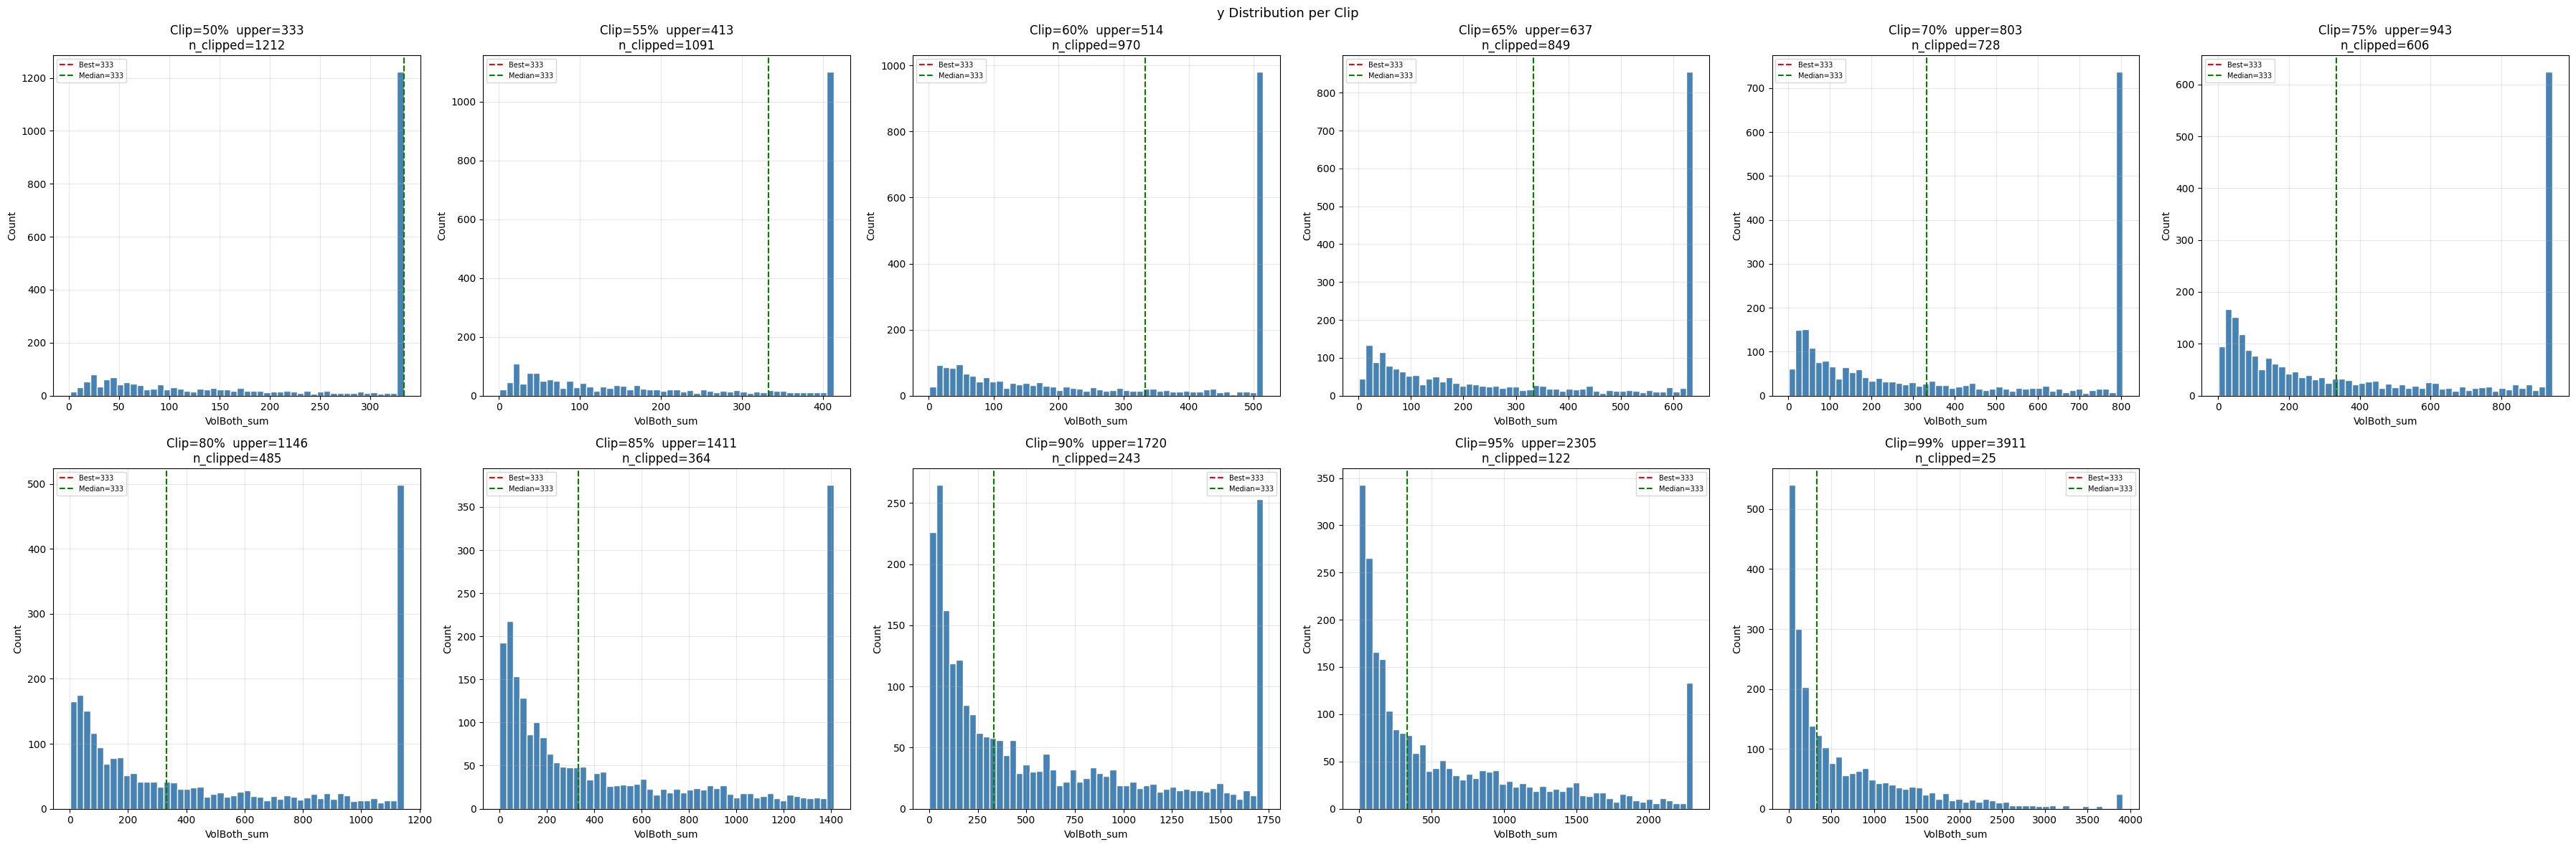

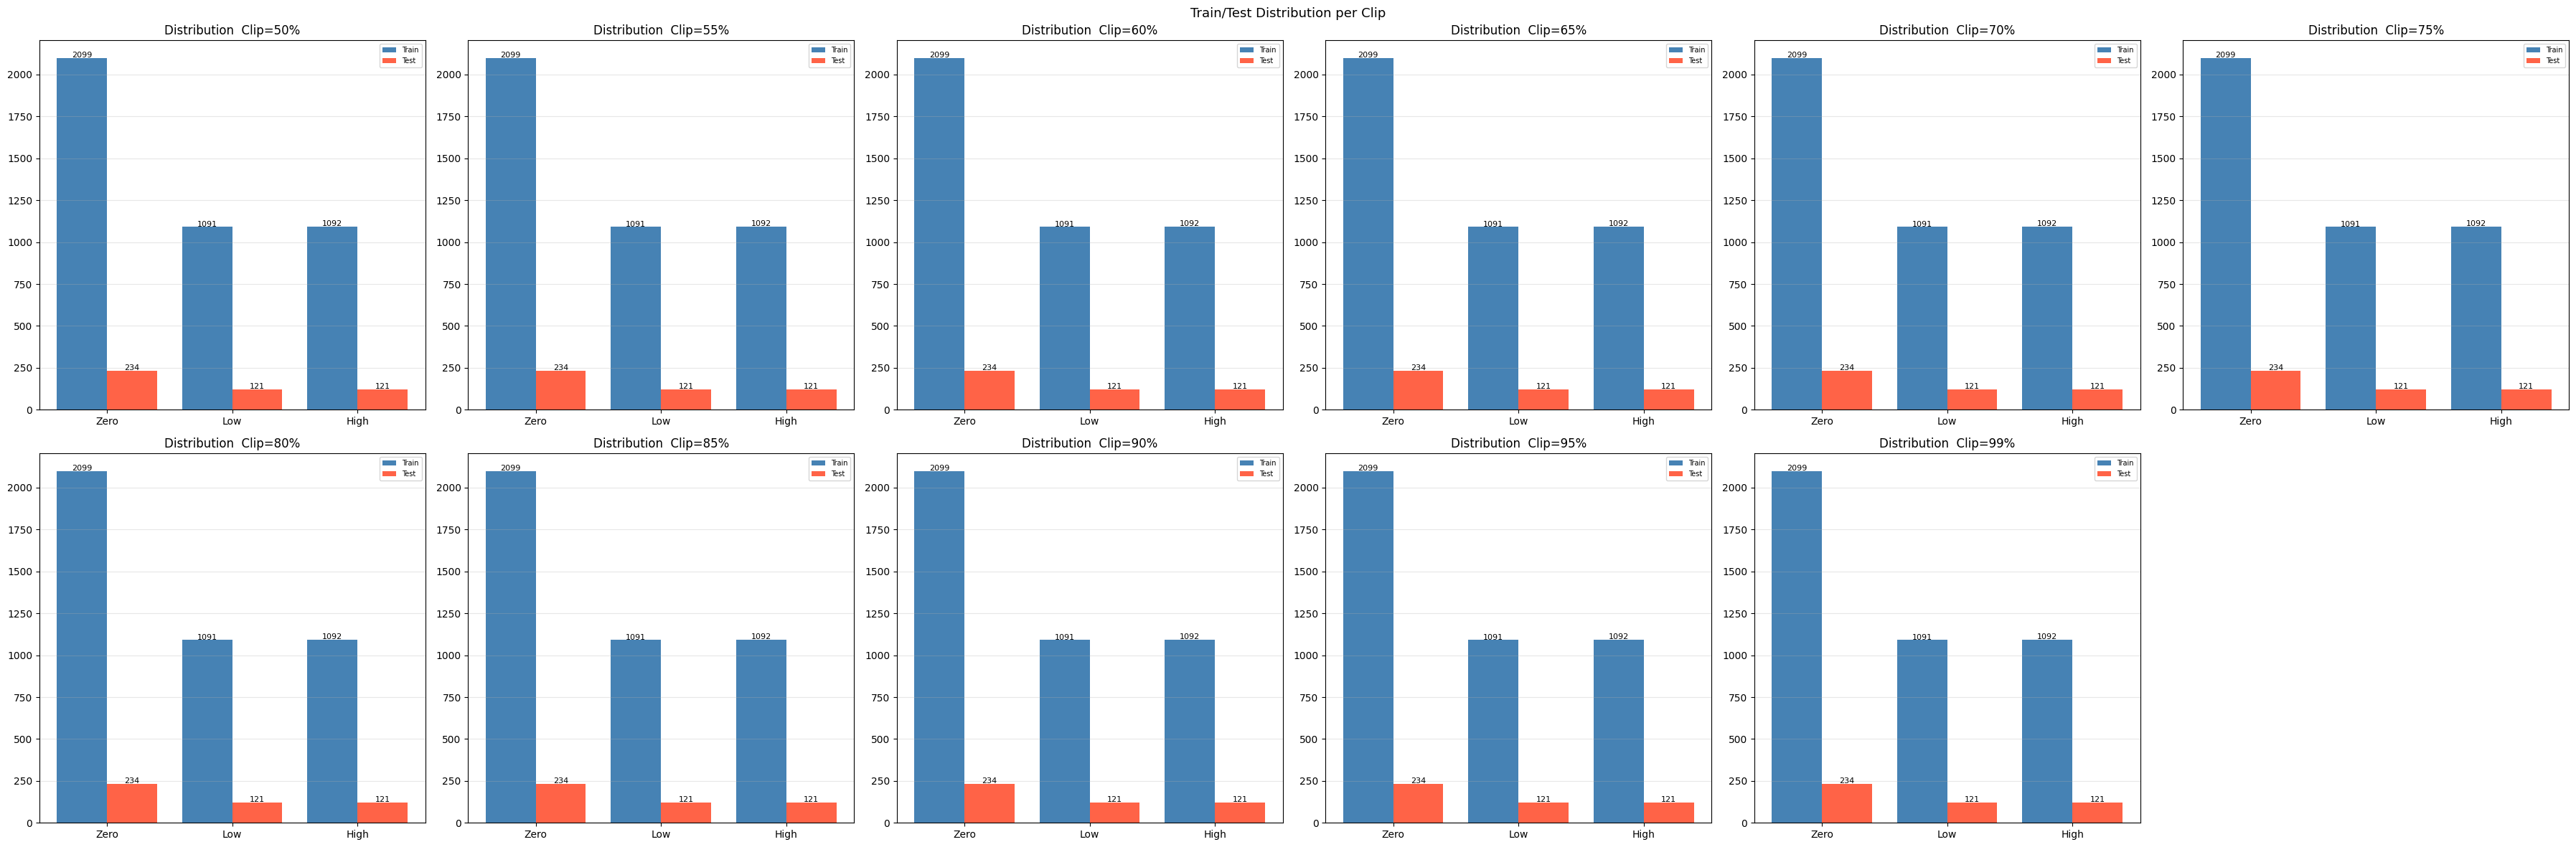

In [ ]:
# =========================================================
# Cell 1: Preprocessing + Split
# =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, mean_squared_error, r2_score
)
# Requires imbalanced-learn: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# =========================
# 0. Load Data
# =========================
df_raw = pd.read_excel("../data/GrideH9_v1.xlsx")
df = df_raw.copy()

# =========================
# 1. Define Target
# =========================
y_reg_raw = df["VolBoth_sum"].copy()

# =========================
# 2. Remove Leakage Features
# =========================
drop_cols = [
    "VolCD","VolVG","VolCD_sum","VolVG_sum","VolBoth_sum",
    "Bin_CD","Bin_VG","Bin_Both",
    "GRID_ID",
    "age_sum","age_med","num_story_sum","num_story_med",
    "sqft_sum","sqft_med",
    "found_ht_sum","found_ht_med",
    "val_struct_sum","val_struct_med",
    "val_cont_sum","val_cont_med","landuse"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# =========================
# 3. X Outlier Clipping
# =========================
log_cols  = ["sqft", "val_struct", "val_cont", "fld_pct"]
cont_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cont_cols = [c for c in cont_cols if not c.startswith(("occtype","bldg"))]
cont_cols = [c for c in cont_cols if c not in ["dist_coast","dist_reservoir"]]
cont_cols = [c for c in cont_cols if c not in log_cols]

clip_summary = []
for col in cont_cols:
    skew = df[col].skew()
    if skew > 3:    upper = df[col].quantile(0.80)
    elif skew > 2:  upper = df[col].quantile(0.90)
    elif skew > 1:  upper = df[col].quantile(0.98)
    else:           upper = df[col].quantile(0.995)
    n_clipped = (df[col] > upper).sum()
    clip_summary.append({
        "feature": col, "skew": round(skew, 2),
        "upper": round(upper, 2), "n_clipped": n_clipped,
        "percent_clipped": round(n_clipped / len(df[col]) * 100, 2)
    })
    df[col] = np.clip(df[col], 0, upper)

clip_df = pd.DataFrame(clip_summary).sort_values(by="percent_clipped", ascending=False)
print("===== X Clipping Summary =====")
print(clip_df)

# =========================
# 4. Log Transform
# =========================
for col in log_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

# =========================
# 5. Binary Distance Features
# =========================
thr_coast = df_raw.loc[df_raw["dist_coast"] > 0, "dist_coast"].quantile(0.10)
thr_res   = df_raw.loc[df_raw["dist_reservoir"] > 0, "dist_reservoir"].quantile(0.10)

df["near_coast"] = ((df_raw["dist_coast"] > 0) &
                    (df_raw["dist_coast"] < thr_coast)).astype(int)
df["near_reservoir"] = ((df_raw["dist_reservoir"] > 0) &
                        (df_raw["dist_reservoir"] < thr_res)).astype(int)
df = df.drop(columns=["dist_coast","dist_reservoir"], errors="ignore")

print("\n=== near_coast ===")
print(f"Close (1): {(df['near_coast']==1).sum()}")
print(f"Far   (0): {(df['near_coast']==0).sum()}")
print("\n=== near_reservoir ===")
print(f"Close (1): {(df['near_reservoir']==1).sum()}")
print(f"Far   (0): {(df['near_reservoir']==0).sum()}")


# =========================
# 6. Dummy Encoding
# =========================
df_model = pd.get_dummies(df.copy(), drop_first=False)

# =========================
# 7. Automate split processing for each clipping level
# =========================
clip_percentiles = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]
y_pos_raw  = y_reg_raw[y_reg_raw > 0]
clip_results = {}

n_clips = len(clip_percentiles)
n_cols  = 6
n_rows  = int(np.ceil(n_clips / n_cols))

fig1, axes1 = plt.subplots(2, 6, figsize=(36, 12))
fig2, axes2 = plt.subplots(2, 6, figsize=(36, 12))
axes1 = axes1.flatten()
axes2 = axes2.flatten()

for i, cp in enumerate(clip_percentiles):

    y_upper   = y_pos_raw.quantile(cp / 100)
    n_clipped = (y_pos_raw > y_upper).sum()
    y_reg_cp  = y_reg_raw.clip(upper=y_upper)
    y_pos_cp  = y_reg_cp[y_reg_cp > 0]

    median_val          = int(y_pos_cp.median())
    thr_candidates_init = list(range(max(50, median_val - 200), median_val + 225, 25))

    thr_results = []
    for thr in thr_candidates_init:
        n_low  = (y_pos_cp <= thr).sum()
        n_high = (y_pos_cp >  thr).sum()
        ratio  = n_low / (n_low + n_high)
        thr_results.append({
            "Threshold": thr,
            "Low_ratio": round(ratio, 3),
            "Balance":   round(abs(ratio - 0.5), 3)
        })

    thr_df_init = pd.DataFrame(thr_results)
    best_thr    = int(thr_df_init.loc[thr_df_init["Balance"].idxmin(), "Threshold"])

    y_stratify = y_reg_cp.apply(
        lambda x: "zero" if x == 0 else ("low" if x <= best_thr else "high")
    )

    X_train_cp, X_test_cp, _, _ = train_test_split(
        df_model, y_stratify,
        test_size=0.1,
        random_state=42,
        stratify=y_stratify
    )

    y_train_cp = y_reg_cp.loc[X_train_cp.index]
    y_test_cp  = y_reg_cp.loc[X_test_cp.index]

    train_zero = (y_train_cp == 0).sum()
    train_low  = ((y_train_cp > 0) & (y_train_cp <= best_thr)).sum()
    train_high = (y_train_cp > best_thr).sum()
    test_zero  = (y_test_cp  == 0).sum()
    test_low   = ((y_test_cp  > 0) & (y_test_cp  <= best_thr)).sum()
    test_high  = (y_test_cp  > best_thr).sum()

    clip_results[cp] = {
        "y_reg":       y_reg_cp,
        "y_upper":     y_upper,
        "n_clipped":   n_clipped,
        "threshold":   best_thr,
        "X_train":     X_train_cp,
        "X_test":      X_test_cp,
        "y_train_reg": y_train_cp,
        "y_test_reg":  y_test_cp,
    }

    print(f"\nClip={cp}%  upper={y_upper:.2f}  n_clipped={n_clipped}  best_thr={best_thr}")
    print(f"Train: {len(X_train_cp)}  Zero={train_zero}  Low={train_low}  High={train_high}  Low_ratio={train_low/(train_low+train_high):.3f}")
    print(f"Test : {len(X_test_cp)}   Zero={test_zero}   Low={test_low}   High={test_high}   Low_ratio={test_low/(test_low+test_high):.3f}")

    # Histogram
    axes1[i].hist(y_pos_cp, bins=50, color="steelblue", edgecolor="white")
    axes1[i].axvline(best_thr,   color="red",   linestyle="--", lw=1.5, label=f"Best={best_thr}")
    axes1[i].axvline(median_val, color="green", linestyle="--", lw=1.5, label=f"Median={median_val}")
    axes1[i].set_title(f"Clip={cp}%  upper={y_upper:.0f}\nn_clipped={n_clipped}")
    axes1[i].set_xlabel("VolBoth_sum")
    axes1[i].set_ylabel("Count")
    axes1[i].legend(fontsize=7); axes1[i].grid(alpha=0.3)

    # Train/Test Distribution
    x = np.arange(3)
    tr_vals = [train_zero, train_low, train_high]
    te_vals = [test_zero,  test_low,  test_high]
    axes2[i].bar(x - 0.2, tr_vals, 0.4, color="steelblue", label="Train")
    axes2[i].bar(x + 0.2, te_vals, 0.4, color="tomato",    label="Test")
    axes2[i].set_xticks(x)
    axes2[i].set_xticklabels(["Zero", "Low", "High"])
    axes2[i].set_title(f"Distribution  Clip={cp}%")
    axes2[i].legend(fontsize=7); axes2[i].grid(alpha=0.3, axis="y")
    for j, (tr, te) in enumerate(zip(tr_vals, te_vals)):
        axes2[i].text(j - 0.2, tr + 3, str(tr), ha="center", fontsize=8)
        axes2[i].text(j + 0.2, te + 3, str(te), ha="center", fontsize=8)

# Hide unused axes
for j in range(i + 1, len(axes1)):
    axes1[j].set_visible(False)
    axes2[j].set_visible(False)

fig1.suptitle("y Distribution per Clip", fontsize=13)
fig1.tight_layout()
fig1.show()

fig2.suptitle("Train/Test Distribution per Clip", fontsize=13)
fig2.tight_layout()
fig2.show()

print("\n[Cell 1 Done]")
print(f"{'Clip':>6} {'Upper':>8} {'N_clip':>8} {'Best_Thr':>10} {'Train':>7} {'Test':>7}")
print("-" * 50)
for cp in clip_percentiles:
    r = clip_results[cp]
    print(f"{cp:>6} {r['y_upper']:>8.2f} {r['n_clipped']:>8} "
          f"{r['threshold']:>10} {len(r['X_train']):>7} {len(r['X_test']):>7}")

Feature Importance

Rank  Feature                          Importance      Used
------------------------------------------------------------
   1  occtype                            0.117531   * TOP20
   2  bldg_type                          0.098012   * TOP20
   3  landcover_Urban and Built Up       0.094027   * TOP20
   4  wind_kph                           0.088266   * TOP20
   5  dist_htrack                        0.075812   * TOP20
   6  evac_degree_none                   0.050085   * TOP20
   7  elev                               0.042083   * TOP20
   8  age                                0.040431   * TOP20
   9  near_coast                         0.037519   * TOP20
  10  TCC_pct                            0.034923   * TOP20
  11  evac_degree_med                    0.034602   * TOP20
  12  rainfall                           0.033672   * TOP20
  13  landcover_Wetlands                 0.029819   * TOP20
  14  fld_zone_X                         0.029567   * TOP20
  15  sqft         

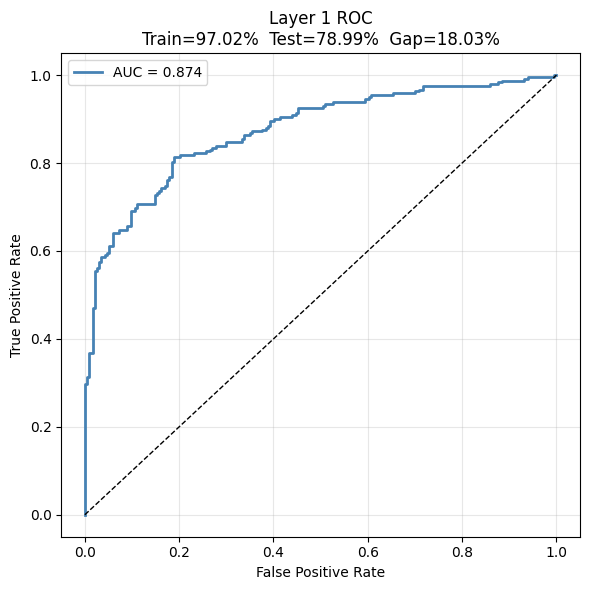


[Positive Samples]
  Train positive : 2183
  Test  positive : 226
  AUC            : 0.8743
  Train Acc      : 97.02%
  Test  Acc      : 78.99%
  Gap            : 18.03%


In [5]:
# =========================================================
# Cell 2-A: Layer 1 — Zero vs Positive Classification
# Fixed at clip=99% (classification result is clip-independent)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_curve, auc
# Requires imbalanced-learn: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

XGB_PARAMS_CLF = dict(
    n_estimators     = 50,
    max_depth        = 10,
    min_child_weight = 10,
    colsample_bynode = 0.8,
    random_state     = 42,
    n_jobs           = -1
)

# Fixed at clip=99% (classification unaffected by y clipping)
cp          = 99
X_train     = clip_results[cp]["X_train"]
X_test      = clip_results[cp]["X_test"]
y_train_reg = clip_results[cp]["y_train_reg"]
y_test_reg  = clip_results[cp]["y_test_reg"]

y_train_binary = (y_train_reg > 0).astype(int)
y_test_binary  = (y_test_reg  > 0).astype(int)

bldg_cols    = [c for c in X_train.columns if c.startswith("bldg")]
occtype_cols = [c for c in X_train.columns if c.startswith("occtype")]
grouped_cols = set(bldg_cols + occtype_cols)

# =========================================================
# Feature Importance
# =========================================================
print("=" * 60)
print("Feature Importance")
print("=" * 60)

xgb_feat = XGBClassifier(**XGB_PARAMS_CLF)
xgb_feat.fit(X_train, y_train_binary)

feat_imp_raw = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_feat.feature_importances_
}).sort_values("importance", ascending=False)

grouped_imp = {}
grouped_imp["bldg_type"] = feat_imp_raw[feat_imp_raw["feature"].isin(bldg_cols)]["importance"].sum()
grouped_imp["occtype"]   = feat_imp_raw[feat_imp_raw["feature"].isin(occtype_cols)]["importance"].sum()
for _, row in feat_imp_raw.iterrows():
    if row["feature"] not in grouped_cols:
        grouped_imp[row["feature"]] = row["importance"]

grouped_imp_df = pd.DataFrame(
    grouped_imp.items(), columns=["feature", "importance"]
).sort_values("importance", ascending=False).reset_index(drop=True)

print(f"\n{'Rank':>4}  {'Feature':30} {'Importance':>12}  {'Used':>8}")
print("-" * 60)
for i, row in grouped_imp_df.iterrows():
    rank = i + 1
    used = "* TOP20" if rank <= 20 else ""
    print(f"{rank:>4}  {row['feature']:30} {row['importance']:>12.6f}  {used:>8}")

# =========================================================
# Top 20 Feature Expansion
# =========================================================
top20_groups = grouped_imp_df.head(20)["feature"].tolist()

def expand_features(group_list, bldg_cols, occtype_cols):
    expanded = []
    for g in group_list:
        if g == "bldg_type":  expanded.extend(bldg_cols)
        elif g == "occtype":  expanded.extend(occtype_cols)
        else:                 expanded.append(g)
    return expanded

top_features = expand_features(top20_groups, bldg_cols, occtype_cols)
print(f"\nTop 20 groups -> expanded {len(top_features)} cols")

# =========================================================
# SMOTE + Classification
# =========================================================
print("\n" + "=" * 60)
print("LAYER 1: Zero vs Positive Classification")
print("=" * 60)

smote_l1 = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote_l1.fit_resample(
    X_train[top_features], y_train_binary
)
print(f"After SMOTE — Zero: {(y_train_sm==0).sum()}  Positive: {(y_train_sm==1).sum()}")

clf_l1 = XGBClassifier(**XGB_PARAMS_CLF)
clf_l1.fit(X_train_sm, y_train_sm)

train_acc_l1 = (clf_l1.predict(X_train_sm) == y_train_sm).mean()
y_pred_l1    = clf_l1.predict(X_test[top_features])
y_prob_l1    = clf_l1.predict_proba(X_test[top_features])[:, 1]
test_acc_l1  = (y_pred_l1 == y_test_binary).mean()

fpr_l1, tpr_l1, _ = roc_curve(y_test_binary, y_prob_l1)
auc_l1 = auc(fpr_l1, tpr_l1)

report = classification_report(
    y_test_binary, y_pred_l1,
    target_names=["Zero", "Positive"],
    output_dict=True,
    zero_division=0
)

print(f"\nTrain Acc : {train_acc_l1*100:.2f}%")
print(f"Test  Acc : {test_acc_l1*100:.2f}%")
print(f"Gap       : {(train_acc_l1-test_acc_l1)*100:.2f}%")
print(f"AUC       : {auc_l1:.4f}")

# =========================================================
# Classification Report
# =========================================================
report_df = pd.DataFrame({
    "Class":        ["Zero", "Positive", "Macro Avg"],
    "Precision(%)": [
        round(report["Zero"]["precision"]      * 100, 2),
        round(report["Positive"]["precision"]  * 100, 2),
        round(report["macro avg"]["precision"] * 100, 2),
    ],
    "Recall(%)": [
        round(report["Zero"]["recall"]      * 100, 2),
        round(report["Positive"]["recall"]  * 100, 2),
        round(report["macro avg"]["recall"] * 100, 2),
    ],
    "F1(%)": [
        round(report["Zero"]["f1-score"]      * 100, 2),
        round(report["Positive"]["f1-score"]  * 100, 2),
        round(report["macro avg"]["f1-score"] * 100, 2),
    ],
})
print("\n=== Classification Report ===")
print(report_df.to_string(index=False))

# =========================================================
# ROC Curve
# =========================================================
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_l1, tpr_l1, color="steelblue", lw=2, label=f"AUC = {auc_l1:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"Layer 1 ROC\n"
    f"Train={train_acc_l1*100:.2f}%  Test={test_acc_l1*100:.2f}%  "
    f"Gap={(train_acc_l1-test_acc_l1)*100:.2f}%"
)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# Extract Positive Samples — stored per clip
# =========================================================
train_pos_mask = y_train_reg > 0
test_pred_pos  = pd.Series(y_pred_l1, index=X_test.index) == 1

clf_results = {}
for cp_reg in [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]:
    y_reg_cp   = clip_results[cp_reg]["y_reg"]
    y_train_cp = y_reg_cp.loc[X_train.index]
    y_test_cp  = y_reg_cp.loc[X_test.index]

    clf_results[cp_reg] = {
        "clf_l1":        clf_l1,
        "top_features":  top_features,
        "bldg_cols":     bldg_cols,
        "occtype_cols":  occtype_cols,
        "grouped_cols":  grouped_cols,
        "auc_l1":        auc_l1,
        "train_acc":     train_acc_l1,
        "test_acc":      test_acc_l1,
        "gap":           train_acc_l1 - test_acc_l1,
        "X_train_pos":   X_train.loc[train_pos_mask],
        "y_train_pos":   y_train_cp.loc[train_pos_mask],
        "X_test_pos":    X_test.loc[test_pred_pos],
        "y_test_pos":    y_test_cp.loc[test_pred_pos],
        "f1_zero":       round(report["Zero"]["f1-score"]      * 100, 2),
        "f1_positive":   round(report["Positive"]["f1-score"]  * 100, 2),
        "f1_macro":      round(report["macro avg"]["f1-score"] * 100, 2),
    }

print(f"\n[Positive Samples]")
print(f"  Train positive : {train_pos_mask.sum()}")
print(f"  Test  positive : {test_pred_pos.sum()}")
print(f"  AUC            : {auc_l1:.4f}")
print(f"  Train Acc      : {train_acc_l1*100:.2f}%")
print(f"  Test  Acc      : {test_acc_l1*100:.2f}%")
print(f"  Gap            : {(train_acc_l1-test_acc_l1)*100:.2f}%")

Threshold candidates: 56  range: 100~1475

Clip=50%
  thr=  150  R2_Tr=99.61%  R2_Te=23.66%  NRMSE_Te=36.65%  COV_Te=56.89%  Err_Te=36.85%
  thr=  175  R2_Tr=99.67%  R2_Te=31.03%  NRMSE_Te=34.83%  COV_Te=54.07%  Err_Te=33.31%
  thr=  200  R2_Tr=99.57%  R2_Te=31.90%  NRMSE_Te=34.61%  COV_Te=53.73%  Err_Te=32.49%
  thr=  225  R2_Tr=99.52%  R2_Te=26.71%  NRMSE_Te=35.91%  COV_Te=55.74%  Err_Te=33.82%
  thr=  250  R2_Tr=99.47%  R2_Te=17.59%  NRMSE_Te=38.08%  COV_Te=59.11%  Err_Te=36.31%
  thr=  275  R2_Tr=98.86%  R2_Te=33.47%  NRMSE_Te=34.21%  COV_Te=53.11%  Err_Te=32.82%
  thr=  300  R2_Tr=98.81%  R2_Te=33.95%  NRMSE_Te=34.09%  COV_Te=52.92%  Err_Te=32.41%
  thr=  325  R2_Tr=98.67%  R2_Te=28.92%  NRMSE_Te=35.36%  COV_Te=54.90%  Err_Te=32.91%

Clip=55%
  thr=  150  R2_Tr=99.35%  R2_Te=25.13%  NRMSE_Te=36.22%  COV_Te=59.39%  Err_Te=39.65%
  thr=  175  R2_Tr=99.63%  R2_Te=29.08%  NRMSE_Te=35.25%  COV_Te=57.80%  Err_Te=37.22%
  thr=  200  R2_Tr=99.64%  R2_Te=28.02%  NRMSE_Te=35.51%  COV_Te=58.

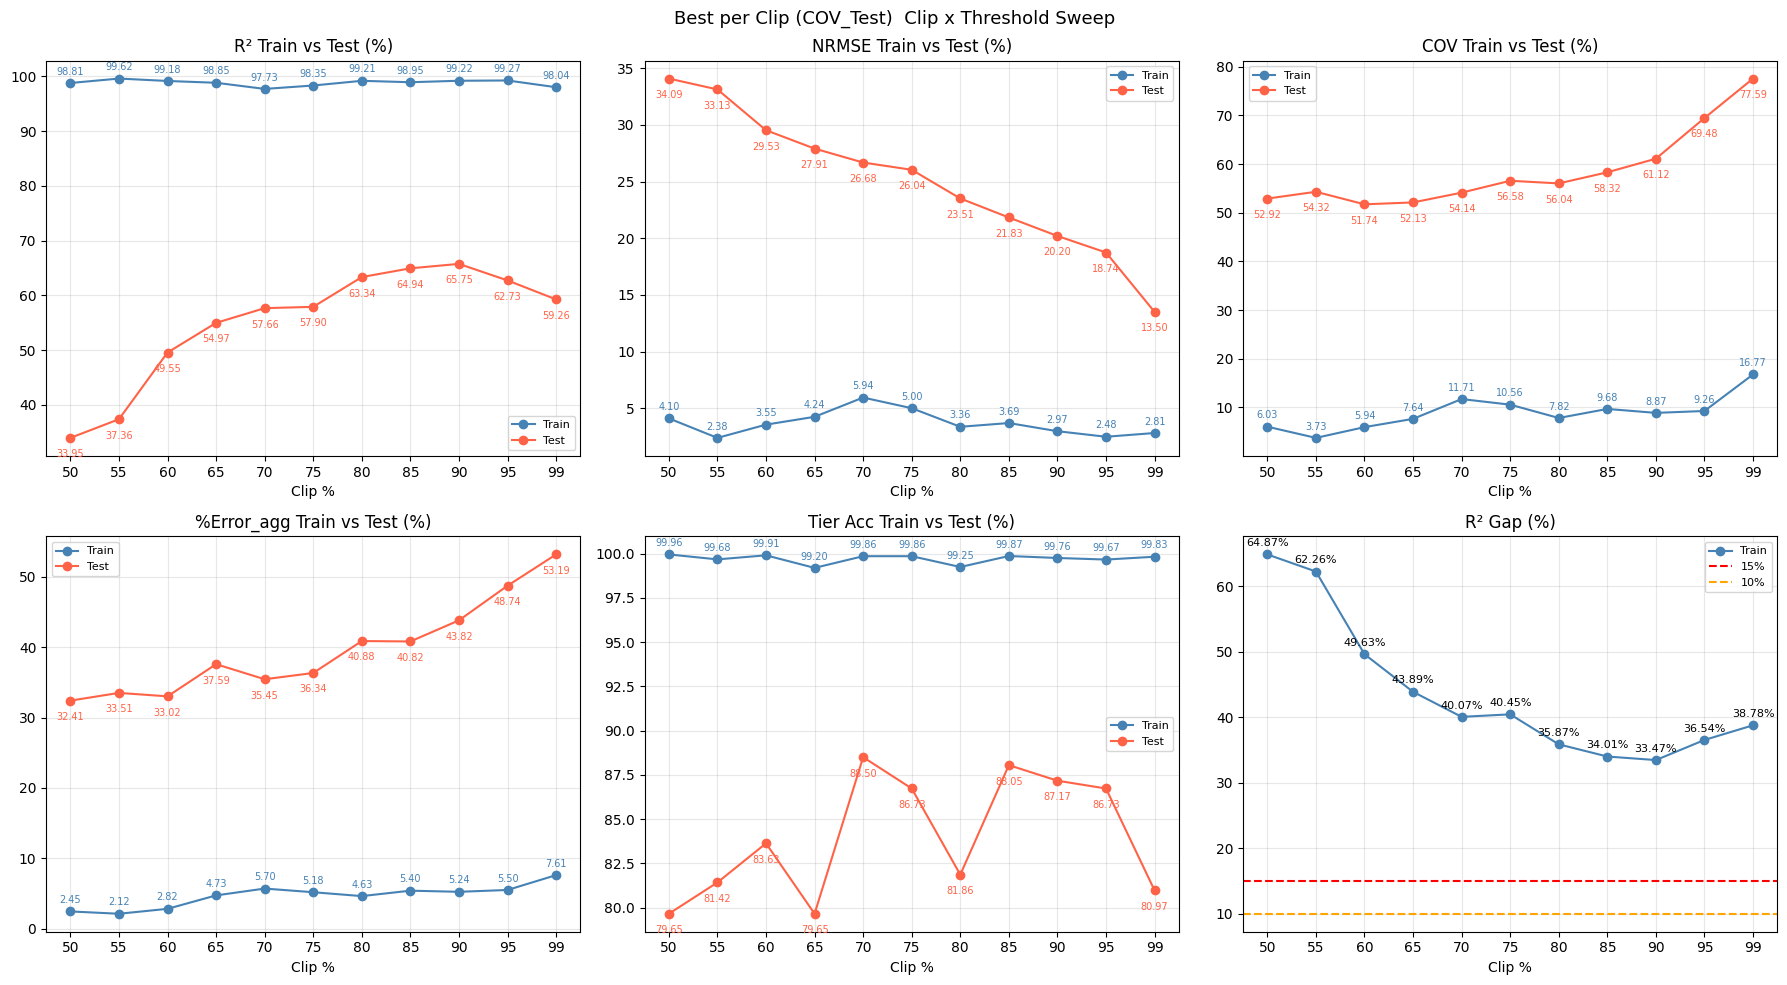


=== Overall Best (COV_Test) ===
  Clip       : 60%
  Threshold  : 350
  R2_Train   : 99.18%
  R2_Test    : 49.55%
  R2_Gap     : 49.63%
  NRMSE_Test : 29.53%
  COV_Train  : 5.94%
  COV_Test   : 51.74%
  Err_Test   : 33.02%
  Tier_Gap   : 16.28%


In [6]:
# =========================================================
# Cell 2-B: Layer 2 — Regression
# Clip x Threshold Sweep (Log Transform)
# =========================================================

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

def calc_metrics(y_true, y_pred):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = np.mean(np.abs(y_true - y_pred))
    r2    = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min()) * 100
    cov   = rmse / y_true.mean()
    agg   = np.abs(y_true - y_pred).sum() / y_true.sum() * 100
    return rmse, mae, r2, nrmse, cov, agg

XGB_PARAMS_REG = dict(
    n_estimators     = 50,
    max_depth        = 6,
    min_child_weight = 1,
    colsample_bynode = 0.8,
    random_state     = 42,
    n_jobs           = -1
)

clip_percentiles = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]
thr_candidates   = list(range(100, 1500, 25))
all_reg_results  = []

print(f"Threshold candidates: {len(thr_candidates)}  range: {thr_candidates[0]}~{thr_candidates[-1]}")

for cp in clip_percentiles:

    print(f"\n{'='*60}")
    print(f"Clip={cp}%")
    print(f"{'='*60}")

    X_train_pos  = clf_results[cp]["X_train_pos"]
    X_test_pos   = clf_results[cp]["X_test_pos"]
    bldg_cols    = clf_results[cp]["bldg_cols"]
    occtype_cols = clf_results[cp]["occtype_cols"]
    grouped_cols = clf_results[cp]["grouped_cols"]

    y_upper  = clip_results[cp]["y_upper"]
    y_reg_cp = clip_results[cp]["y_reg"]

    y_tr_pos = y_reg_cp.loc[X_train_pos.index]
    y_te_pos = y_reg_cp.loc[X_test_pos.index]

    # Regression Feature Importance (once per clip)
    reg_feat_tmp = XGBRegressor(**XGB_PARAMS_REG)
    reg_feat_tmp.fit(X_train_pos, np.log1p(y_tr_pos))

    fi_reg_raw = pd.DataFrame({
        "Feature":    X_train_pos.columns,
        "Importance": reg_feat_tmp.feature_importances_
    }).sort_values("Importance", ascending=False)

    grouped_imp_reg = {}
    grouped_imp_reg["bldg_type"] = fi_reg_raw[fi_reg_raw["Feature"].isin(bldg_cols)]["Importance"].sum()
    grouped_imp_reg["occtype"]   = fi_reg_raw[fi_reg_raw["Feature"].isin(occtype_cols)]["Importance"].sum()
    for _, row in fi_reg_raw.iterrows():
        if row["Feature"] not in grouped_cols:
            grouped_imp_reg[row["Feature"]] = row["Importance"]

    grouped_imp_reg_df = pd.DataFrame(
        grouped_imp_reg.items(), columns=["feature", "importance"]
    ).sort_values("importance", ascending=False).reset_index(drop=True)

    top20_reg_groups = grouped_imp_reg_df.head(20)["feature"].tolist()
    top20_reg        = expand_features(top20_reg_groups, bldg_cols, occtype_cols)

    for thr in thr_candidates:

        if thr >= y_upper:
            continue

        low_mask_tr  = y_tr_pos <= thr
        high_mask_tr = y_tr_pos >  thr

        n_low_tr  = low_mask_tr.sum()
        n_high_tr = high_mask_tr.sum()

        if n_low_tr < 5 or n_high_tr < 5:
            continue

        low_ratio = n_low_tr / (n_low_tr + n_high_tr)
        if not (0.30 <= low_ratio <= 0.70):
            continue

        # Tier Classifier
        tier_label_tr = pd.Series(
            np.where(y_tr_pos <= thr, 0, 1),
            index=y_tr_pos.index
        )
        try:
            smote_l2 = SMOTE(random_state=42)
            X_sm_l2, y_sm_l2 = smote_l2.fit_resample(
                X_train_pos[top20_reg], tier_label_tr
            )
        except Exception:
            X_sm_l2 = X_train_pos[top20_reg]
            y_sm_l2 = tier_label_tr

        clf_tier = XGBClassifier(**XGB_PARAMS_REG)
        clf_tier.fit(X_sm_l2, y_sm_l2)

        train_tier_acc = (clf_tier.predict(X_sm_l2) == y_sm_l2).mean()
        tier_pred      = clf_tier.predict(X_test_pos[top20_reg])
        tier_true      = np.where(y_te_pos <= thr, 0, 1)
        test_tier_acc  = (tier_pred == tier_true).mean()

        low_pred_te  = tier_pred == 0
        high_pred_te = tier_pred == 1

        # Regressor Low (Log)
        reg_low = XGBRegressor(**XGB_PARAMS_REG)
        reg_low.fit(
            X_train_pos[top20_reg][low_mask_tr],
            np.log1p(y_tr_pos[low_mask_tr])
        )

        # Regressor High (Log)
        reg_high = XGBRegressor(**XGB_PARAMS_REG)
        reg_high.fit(
            X_train_pos[top20_reg][high_mask_tr],
            np.log1p(y_tr_pos[high_mask_tr])
        )

        # Train Prediction
        y_pred_train = np.zeros(len(y_tr_pos))
        y_pred_train[low_mask_tr]  = np.expm1(reg_low.predict(X_train_pos[top20_reg][low_mask_tr]))
        y_pred_train[high_mask_tr] = np.expm1(reg_high.predict(X_train_pos[top20_reg][high_mask_tr]))
        y_pred_train = np.clip(y_pred_train, 0, None)

        # Test Prediction
        y_pred_test = np.zeros(len(y_te_pos))
        if low_pred_te.sum() > 0:
            y_pred_test[low_pred_te]  = np.expm1(reg_low.predict(X_test_pos[top20_reg][low_pred_te]))
        if high_pred_te.sum() > 0:
            y_pred_test[high_pred_te] = np.expm1(reg_high.predict(X_test_pos[top20_reg][high_pred_te]))
        y_pred_test = np.clip(y_pred_test, 0, None)

        rmse_tr, _, r2_tr, nrmse_tr, cov_tr, agg_tr = calc_metrics(y_tr_pos.values, y_pred_train)
        rmse_te, _, r2_te, nrmse_te, cov_te, agg_te = calc_metrics(y_te_pos.values, y_pred_test)

        all_reg_results.append({
            "Clip":        cp,
            "Threshold":   thr,
            "Low_ratio":   round(low_ratio,  3),
            "Tier_Train":  round(train_tier_acc * 100, 2),
            "Tier_Test":   round(test_tier_acc  * 100, 2),
            "Tier_Gap":    round((train_tier_acc - test_tier_acc) * 100, 2),
            "R2_Train":    round(r2_tr   * 100, 2),
            "R2_Test":     round(r2_te   * 100, 2),
            "R2_Gap":      round((r2_tr - r2_te) * 100, 2),
            "NRMSE_Train": round(nrmse_tr,      2),
            "NRMSE_Test":  round(nrmse_te,      2),
            "COV_Train":   round(cov_tr  * 100, 2),
            "COV_Test":    round(cov_te  * 100, 2),
            "Err_Train":   round(agg_tr,        2),
            "Err_Test":    round(agg_te,        2),
        })

        print(f"  thr={thr:5d}  R2_Tr={r2_tr*100:.2f}%  R2_Te={r2_te*100:.2f}%  "
              f"NRMSE_Te={nrmse_te:.2f}%  COV_Te={cov_te*100:.2f}%  "
              f"Err_Te={agg_te:.2f}%")

all_reg_df = pd.DataFrame(all_reg_results)

# =========================================================
# Best per Clip (COV_Test)
# =========================================================
best_per_clip = []

for cp in clip_percentiles:
    subset = all_reg_df[all_reg_df["Clip"] == cp]
    best   = subset.loc[subset["COV_Test"].idxmin()]
    best_per_clip.append({
        "Clip":        cp,
        "Best_Thr":    int(best["Threshold"]),
        "Low_ratio":   best["Low_ratio"],
        "R2_Train":    best["R2_Train"],
        "R2_Test":     best["R2_Test"],
        "R2_Gap":      best["R2_Gap"],
        "NRMSE_Train": best["NRMSE_Train"],
        "NRMSE_Test":  best["NRMSE_Test"],
        "COV_Train":   best["COV_Train"],
        "COV_Test":    best["COV_Test"],
        "Err_Train":   best["Err_Train"],
        "Err_Test":    best["Err_Test"],
        "Tier_Train":  best["Tier_Train"],
        "Tier_Test":   best["Tier_Test"],
        "Tier_Gap":    best["Tier_Gap"],
    })

best_df = pd.DataFrame(best_per_clip)

print("\n" + "="*110)
print("=== Best per Clip (COV_Test) ===")
print("="*110)
print(f"{'Clip':>6} {'Thr':>6} {'Low_r':>7} "
      f"{'R2_Tr':>8} {'R2_Te':>8} {'R2_Gap':>8} "
      f"{'NRMSE_Tr':>10} {'NRMSE_Te':>10} "
      f"{'COV_Tr':>8} {'COV_Te':>8} "
      f"{'Err_Tr':>8} {'Err_Te':>8} "
      f"{'Tier_Gap':>10}")
print("-" * 110)
for _, row in best_df.iterrows():
    print(f"{int(row['Clip']):>6} {int(row['Best_Thr']):>6} {row['Low_ratio']:>7.3f} "
          f"{row['R2_Train']:>8.2f} {row['R2_Test']:>8.2f} {row['R2_Gap']:>8.2f} "
          f"{row['NRMSE_Train']:>10.2f} {row['NRMSE_Test']:>10.2f} "
          f"{row['COV_Train']:>8.2f} {row['COV_Test']:>8.2f} "
          f"{row['Err_Train']:>8.2f} {row['Err_Test']:>8.2f} "
          f"{row['Tier_Gap']:>10.2f}")

# =========================================================
# Visualization: Best per Clip Comparison
# =========================================================
clips = [str(cp) for cp in clip_percentiles]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_plot = [
    ("R2_Train",    "R2_Test",    "R² Train vs Test (%)"),
    ("NRMSE_Train", "NRMSE_Test", "NRMSE Train vs Test (%)"),
    ("COV_Train",   "COV_Test",   "COV Train vs Test (%)"),
    ("Err_Train",   "Err_Test",   "%Error_agg Train vs Test (%)"),
    ("Tier_Train",  "Tier_Test",  "Tier Acc Train vs Test (%)"),
    ("R2_Gap",      None,         "R² Gap (%)"),
]

for ax, (tr_col, te_col, title) in zip(axes.flatten(), metrics_plot):
    tr_vals = best_df[tr_col].tolist()
    ax.plot(clips, tr_vals, "o-", color="steelblue", label="Train")
    if te_col:
        te_vals = best_df[te_col].tolist()
        ax.plot(clips, te_vals, "o-", color="tomato", label="Test")
        for i, (tr, te) in enumerate(zip(tr_vals, te_vals)):
            ax.annotate(f"{tr:.2f}", (i, tr), textcoords="offset points",
                        xytext=(0,  6), ha="center", fontsize=7, color="steelblue")
            ax.annotate(f"{te:.2f}", (i, te), textcoords="offset points",
                        xytext=(0,-14), ha="center", fontsize=7, color="tomato")
    else:
        for i, v in enumerate(tr_vals):
            ax.annotate(f"{v:.2f}%", (i, v), textcoords="offset points",
                        xytext=(0, 6), ha="center", fontsize=8)
        ax.axhline(15, color="red",    linestyle="--", lw=1.5, label="15%")
        ax.axhline(10, color="orange", linestyle="--", lw=1.5, label="10%")
    ax.set_title(title)
    ax.set_xlabel("Clip %")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Best per Clip (COV_Test)  Clip x Threshold Sweep", fontsize=13)
plt.tight_layout()
plt.show()

# =========================================================
# Overall Best
# =========================================================
best_overall = best_df.loc[best_df["COV_Test"].idxmin()]
print(f"\n=== Overall Best (COV_Test) ===")
print(f"  Clip       : {int(best_overall['Clip'])}%")
print(f"  Threshold  : {int(best_overall['Best_Thr'])}")
print(f"  R2_Train   : {best_overall['R2_Train']}%")
print(f"  R2_Test    : {best_overall['R2_Test']}%")
print(f"  R2_Gap     : {best_overall['R2_Gap']}%")
print(f"  NRMSE_Test : {best_overall['NRMSE_Test']}%")
print(f"  COV_Train  : {best_overall['COV_Train']}%")
print(f"  COV_Test   : {best_overall['COV_Test']}%")
print(f"  Err_Test   : {best_overall['Err_Test']}%")
print(f"  Tier_Gap   : {best_overall['Tier_Gap']}%")


Clip=50%  thr=325
n=    5  R2=82.71%  NRMSE=15.62%  COV=23.01%  Err=11.54%
n=   10  R2=87.39%  NRMSE=13.34%  COV=19.65%  Err=9.54%
n=   15  R2=90.77%  NRMSE=11.41%  COV=16.81%  Err=8.00%
n=   20  R2=93.23%  NRMSE=9.78%  COV=14.40%  Err=6.68%
n=   25  R2=94.52%  NRMSE=8.79%  COV=12.95%  Err=5.86%
n=   30  R2=95.85%  NRMSE=7.65%  COV=11.27%  Err=5.01%
n=   35  R2=96.85%  NRMSE=6.67%  COV=9.82%  Err=4.24%
n=   40  R2=97.54%  NRMSE=5.89%  COV=8.68%  Err=3.71%
n=   45  R2=98.16%  NRMSE=5.10%  COV=7.51%  Err=3.16%
n=   50  R2=98.67%  NRMSE=4.33%  COV=6.38%  Err=2.65%
n=   55  R2=98.94%  NRMSE=3.86%  COV=5.69%  Err=2.29%
n=   60  R2=99.17%  NRMSE=3.42%  COV=5.04%  Err=2.01%
n=   65  R2=99.39%  NRMSE=2.93%  COV=4.31%  Err=1.69%
n=   70  R2=99.56%  NRMSE=2.49%  COV=3.67%  Err=1.41%
n=   75  R2=99.65%  NRMSE=2.21%  COV=3.26%  Err=1.26%
n=   80  R2=99.75%  NRMSE=1.87%  COV=2.75%  Err=1.06%
n=   85  R2=99.81%  NRMSE=1.62%  COV=2.38%  Err=0.93%
n=   90  R2=99.86%  NRMSE=1.41%  COV=2.07%  Err=0.81%

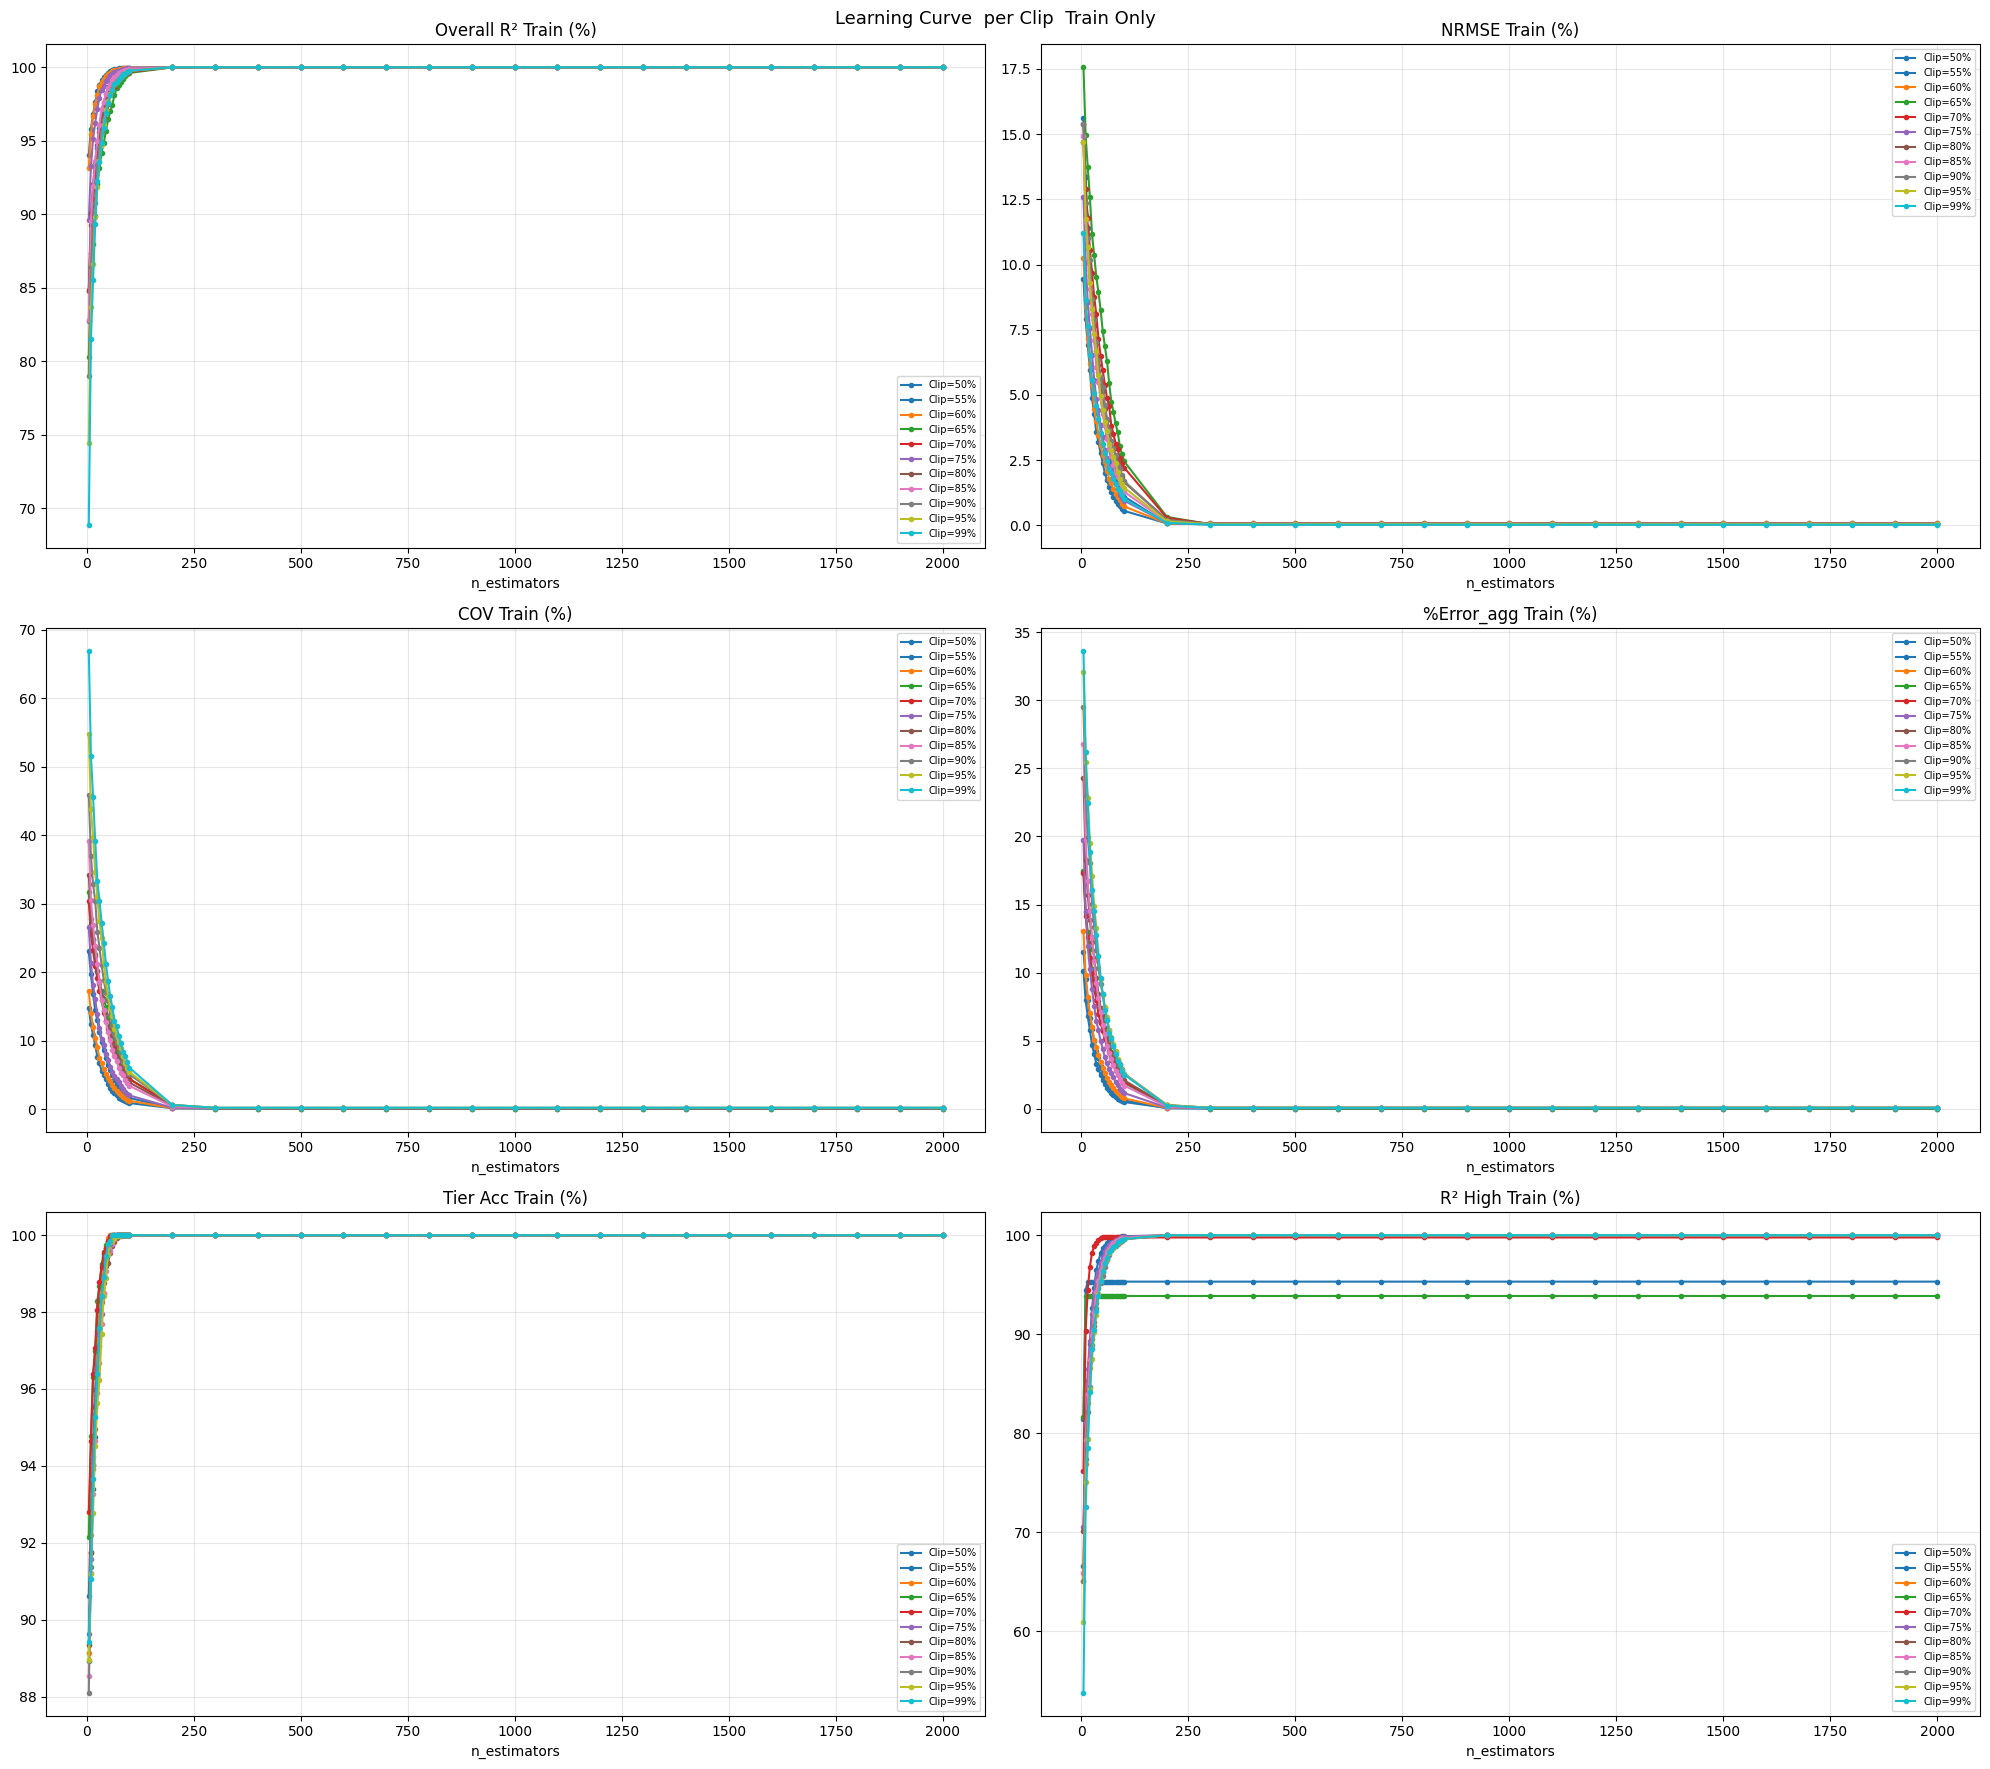


=== Summary at n=50 ===
  Clip    Thr    R2(%)   NRMSE(%)   COV(%)   Err(%)  Tier(%)
------------------------------------------------------------
    50    325    98.67       4.33     6.38     2.65    99.86
    55    225    99.62       2.38     3.73     2.12    99.68
    60    200    99.53       2.70     4.52     2.99    99.92
    65    625    96.45       7.45    13.44     6.36    99.79
    70    725    97.73       5.94    11.71     5.70    99.86
    75    200    99.25       3.38     7.14     4.40    99.73
    80    150    98.14       5.15    12.01     6.81    99.27
    85    175    98.59       4.27    11.20     6.20    99.52
    90    150    97.51       5.30    15.81     8.46    99.58
    95    150    97.67       4.44    16.55     8.39    99.48
    99    175    97.56       3.13    18.73     8.44    99.78


In [7]:
# =========================================================
# Cell 2-C: Learning Curve(Training)
# Best threshold per clip, n_estimators sweep
# =========================================================

# Best threshold per clip (update after Cell 2-B results)
best_thr_by_clip = {
    50: 325,
    55: 225,
    60: 200,
    65: 625,
    70: 725,
    75: 200,
    80: 150,
    85: 175,
    90: 150,
    95: 150,
    99: 175,
}
n_estimators_list = list(range(5, 105, 5)) + list(range(200, 2100, 100))

lc_results = {}

for cp in clip_percentiles:

    thr = best_thr_by_clip[cp]
    print(f"\n{'='*60}")
    print(f"Clip={cp}%  thr={thr}")
    print(f"{'='*60}")

    X_train_pos  = clf_results[cp]["X_train_pos"]
    bldg_cols    = clf_results[cp]["bldg_cols"]
    occtype_cols = clf_results[cp]["occtype_cols"]
    grouped_cols = clf_results[cp]["grouped_cols"]

    y_reg_cp = clip_results[cp]["y_reg"]
    y_tr_pos = y_reg_cp.loc[X_train_pos.index]

    low_mask_tr  = y_tr_pos <= thr
    high_mask_tr = y_tr_pos >  thr

    # Regression Feature Importance
    reg_feat_tmp = XGBRegressor(
        n_estimators=50, max_depth=6, min_child_weight=1,
        colsample_bynode=0.8, random_state=42, n_jobs=-1
    )
    reg_feat_tmp.fit(X_train_pos, np.log1p(y_tr_pos))

    fi_reg_raw = pd.DataFrame({
        "Feature":    X_train_pos.columns,
        "Importance": reg_feat_tmp.feature_importances_
    }).sort_values("Importance", ascending=False)

    grouped_imp_reg = {}
    grouped_imp_reg["bldg_type"] = fi_reg_raw[fi_reg_raw["Feature"].isin(bldg_cols)]["Importance"].sum()
    grouped_imp_reg["occtype"]   = fi_reg_raw[fi_reg_raw["Feature"].isin(occtype_cols)]["Importance"].sum()
    for _, row in fi_reg_raw.iterrows():
        if row["Feature"] not in grouped_cols:
            grouped_imp_reg[row["Feature"]] = row["Importance"]

    grouped_imp_reg_df = pd.DataFrame(
        grouped_imp_reg.items(), columns=["feature", "importance"]
    ).sort_values("importance", ascending=False).reset_index(drop=True)

    top20_reg_groups = grouped_imp_reg_df.head(20)["feature"].tolist()
    top20_reg        = expand_features(top20_reg_groups, bldg_cols, occtype_cols)

    # Tier Classifier SMOTE (n=50 fixed)
    tier_label_tr = pd.Series(
        np.where(y_tr_pos <= thr, 0, 1),
        index=y_tr_pos.index
    )
    try:
        smote_l2 = SMOTE(random_state=42)
        X_sm_l2, y_sm_l2 = smote_l2.fit_resample(
            X_train_pos[top20_reg], tier_label_tr
        )
    except Exception:
        X_sm_l2 = X_train_pos[top20_reg]
        y_sm_l2 = tier_label_tr

    clip_lc = []

    for n in n_estimators_list:
        params = dict(
            n_estimators     = n,
            max_depth        = 6,
            min_child_weight = 1,
            colsample_bynode = 0.8,
            random_state     = 42,
            n_jobs           = -1
        )

        # Tier Classifier
        clf = XGBClassifier(**params)
        clf.fit(X_sm_l2, y_sm_l2)
        train_tier_acc = (clf.predict(X_sm_l2) == y_sm_l2).mean()

        # Regressor Low
        reg_l = XGBRegressor(**params)
        reg_l.fit(X_train_pos[top20_reg][low_mask_tr], np.log1p(y_tr_pos[low_mask_tr]))
        train_pred_low  = np.expm1(reg_l.predict(X_train_pos[top20_reg][low_mask_tr]))
        r2_train_low    = r2_score(y_tr_pos[low_mask_tr], train_pred_low)

        # Regressor High
        reg_h = XGBRegressor(**params)
        reg_h.fit(X_train_pos[top20_reg][high_mask_tr], np.log1p(y_tr_pos[high_mask_tr]))
        train_pred_high = np.expm1(reg_h.predict(X_train_pos[top20_reg][high_mask_tr]))
        r2_train_high   = r2_score(y_tr_pos[high_mask_tr], train_pred_high)

        # Overall Train
        y_pred_train = np.zeros(len(y_tr_pos))
        y_pred_train[low_mask_tr]  = train_pred_low
        y_pred_train[high_mask_tr] = train_pred_high
        y_pred_train = np.clip(y_pred_train, 0, None)

        rmse, _, r2, nrmse, cov, agg = calc_metrics(y_tr_pos.values, y_pred_train)

        clip_lc.append({
            "n_estimators":      n,
            "Tier_Train(%)":     round(train_tier_acc * 100, 2),
            "R2_Low_Train(%)":   round(r2_train_low   * 100, 2),
            "R2_High_Train(%)":  round(r2_train_high  * 100, 2),
            "R2_Overall(%)":     round(r2    * 100, 2),
            "NRMSE(%)":          round(nrmse,       2),
            "COV(%)":            round(cov   * 100, 2),
            "%Error_agg":        round(agg,         2),
        })

        print(f"n={n:5d}  R2={r2:.2%}  NRMSE={nrmse:.2f}%  COV={cov*100:.2f}%  Err={agg:.2f}%")

    lc_results[cp] = pd.DataFrame(clip_lc)

# =========================================================
# Plot: Learning Curve per Clip
# =========================================================
cmap   = plt.cm.tab10
colors = {cp: cmap(i / len(clip_percentiles)) for i, cp in enumerate(clip_percentiles)}

metrics_plot = [
    ("R2_Overall(%)",    "Overall R² Train (%)"),
    ("NRMSE(%)",         "NRMSE Train (%)"),
    ("COV(%)",           "COV Train (%)"),
    ("%Error_agg",       "%Error_agg Train (%)"),
    ("Tier_Train(%)",    "Tier Acc Train (%)"),
    ("R2_High_Train(%)", "R² High Train (%)"),
]

fig, axes = plt.subplots(3, 2, figsize=(20, 18))

for ax, (metric, title) in zip(axes.flatten(), metrics_plot):
    for cp in clip_percentiles:
        df = lc_results[cp]
        ax.plot(df["n_estimators"], df[metric],
                "o-", color=colors[cp], markersize=3,
                label=f"Clip={cp}%")
    ax.set_title(title)
    ax.set_xlabel("n_estimators")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Learning Curve  per Clip  Train Only", fontsize=13)
plt.tight_layout()
plt.show()

# =========================================================
# Summary: n=50 per clip
# =========================================================
print("\n=== Summary at n=50 ===")
print(f"{'Clip':>6} {'Thr':>6} {'R2(%)':>8} {'NRMSE(%)':>10} "
      f"{'COV(%)':>8} {'Err(%)':>8} {'Tier(%)':>8}")
print("-" * 60)
for cp in clip_percentiles:
    df  = lc_results[cp]
    row = df[df["n_estimators"] == 50].iloc[0]
    print(f"{cp:>6} {best_thr_by_clip[cp]:>6} "
          f"{row['R2_Overall(%)']:>8.2f} {row['NRMSE(%)']:>10.2f} "
          f"{row['COV(%)']:>8.2f} {row['%Error_agg']:>8.2f} "
          f"{row['Tier_Train(%)']:>8.2f}")


Clip=50%  thr=325
n=   5  R2_Tr=82.71%  R2_Te=30.70%  COV_Tr=23.01%  COV_Te=54.20%  Err_Tr=11.54%  Err_Te=32.69%
n=  10  R2_Tr=87.39%  R2_Te=29.60%  COV_Tr=19.65%  COV_Te=54.63%  Err_Tr=9.54%  Err_Te=32.69%
n=  15  R2_Tr=90.77%  R2_Te=32.52%  COV_Tr=16.81%  COV_Te=53.49%  Err_Tr=8.00%  Err_Te=31.82%
n=  20  R2_Tr=93.23%  R2_Te=32.23%  COV_Tr=14.40%  COV_Te=53.60%  Err_Tr=6.68%  Err_Te=31.73%
n=  25  R2_Tr=94.52%  R2_Te=27.74%  COV_Tr=12.95%  COV_Te=55.35%  Err_Tr=5.86%  Err_Te=33.71%
n=  30  R2_Tr=95.85%  R2_Te=31.00%  COV_Tr=11.27%  COV_Te=54.09%  Err_Tr=5.01%  Err_Te=32.08%
n=  35  R2_Tr=96.85%  R2_Te=31.36%  COV_Tr=9.82%  COV_Te=53.95%  Err_Tr=4.24%  Err_Te=32.39%
n=  40  R2_Tr=97.54%  R2_Te=31.78%  COV_Tr=8.68%  COV_Te=53.78%  Err_Tr=3.71%  Err_Te=32.13%
n=  45  R2_Tr=98.16%  R2_Te=35.55%  COV_Tr=7.51%  COV_Te=52.27%  Err_Tr=3.16%  Err_Te=31.19%
n=  50  R2_Tr=98.67%  R2_Te=28.92%  COV_Tr=6.38%  COV_Te=54.90%  Err_Tr=2.65%  Err_Te=32.91%
n=  55  R2_Tr=98.94%  R2_Te=30.75%  COV_Tr=5

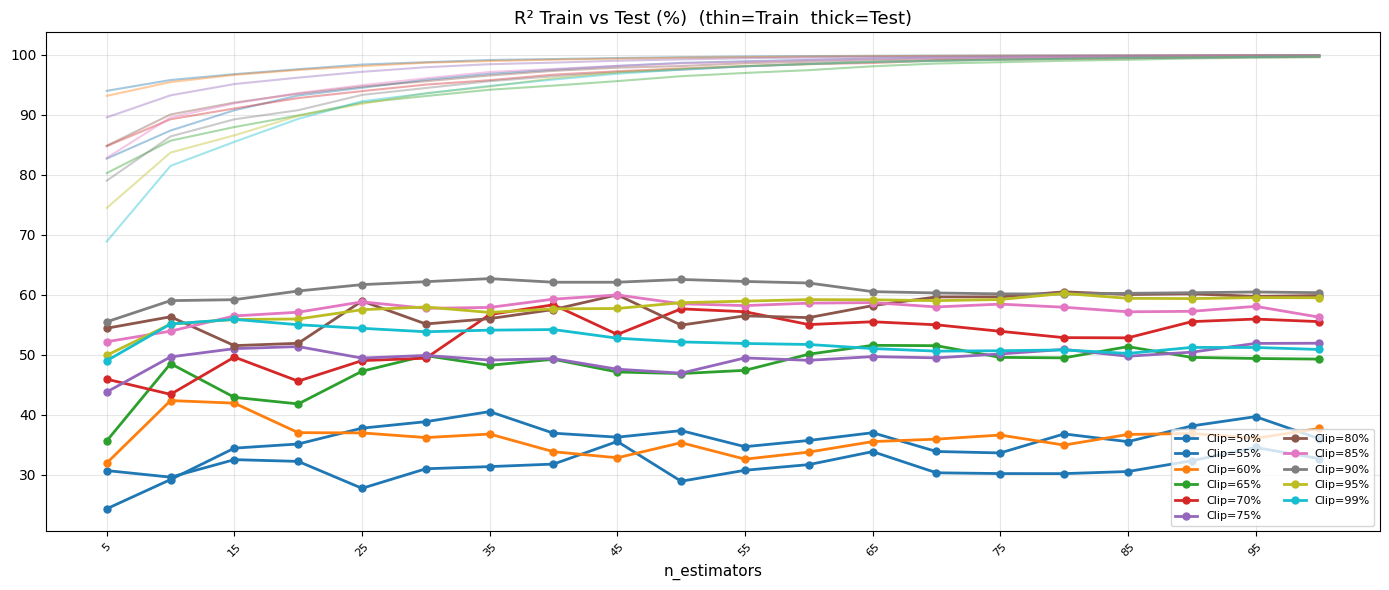

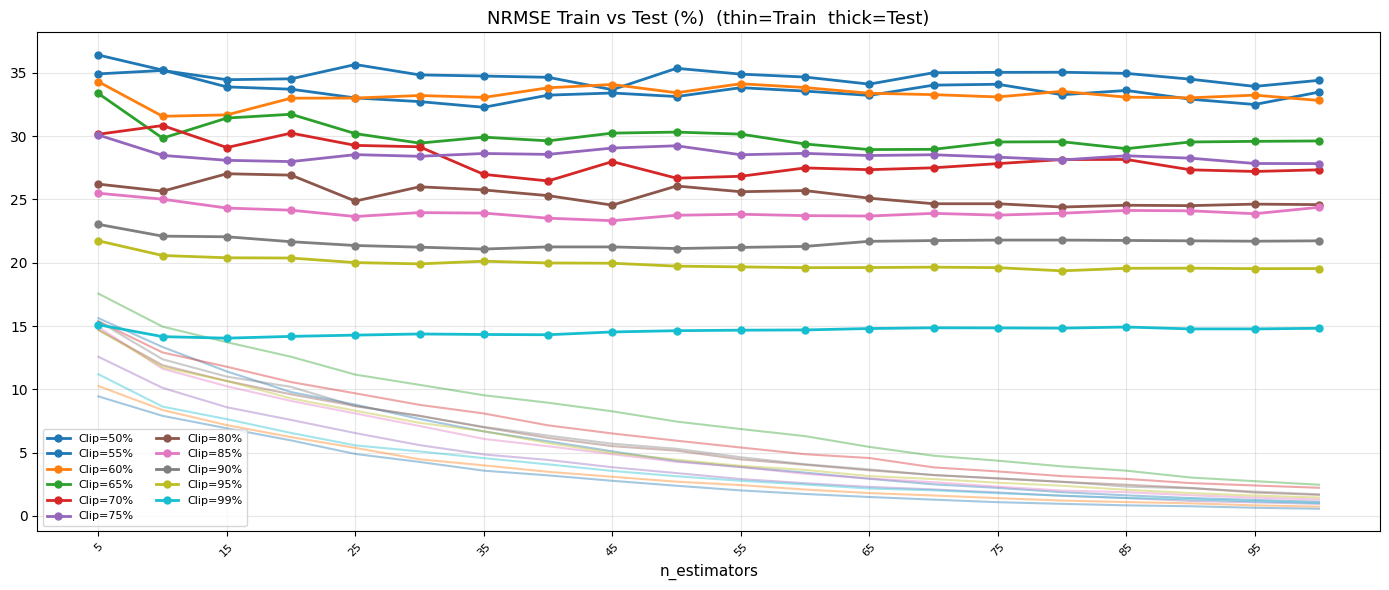

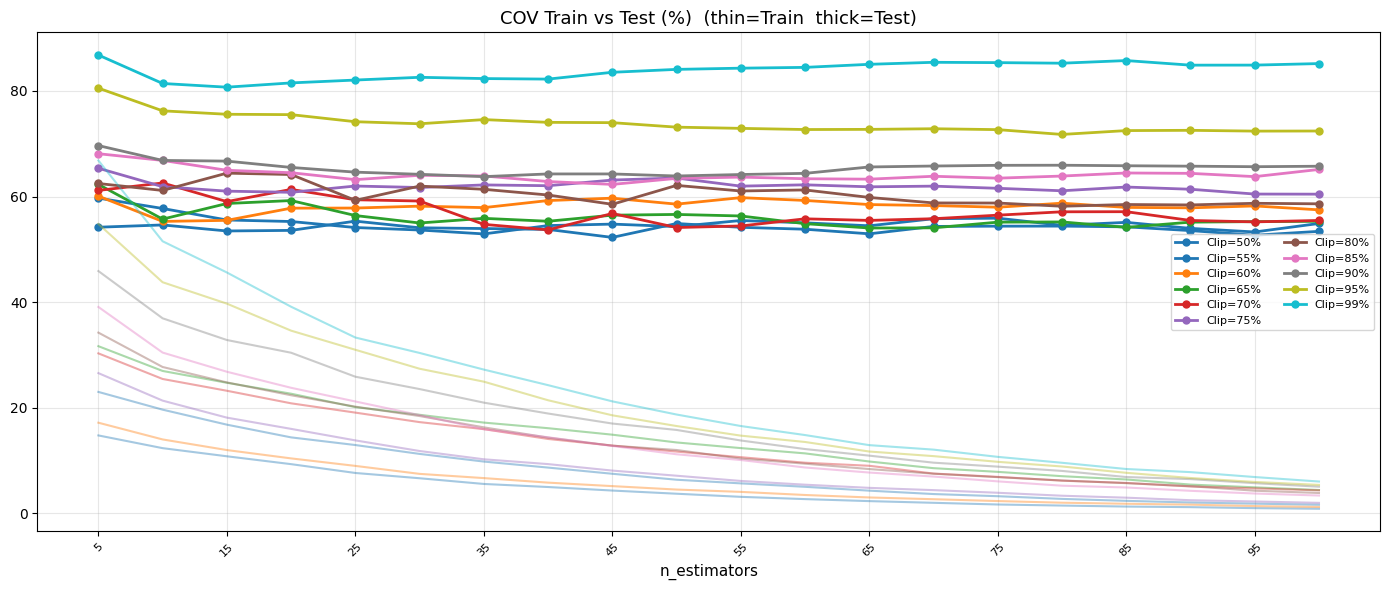

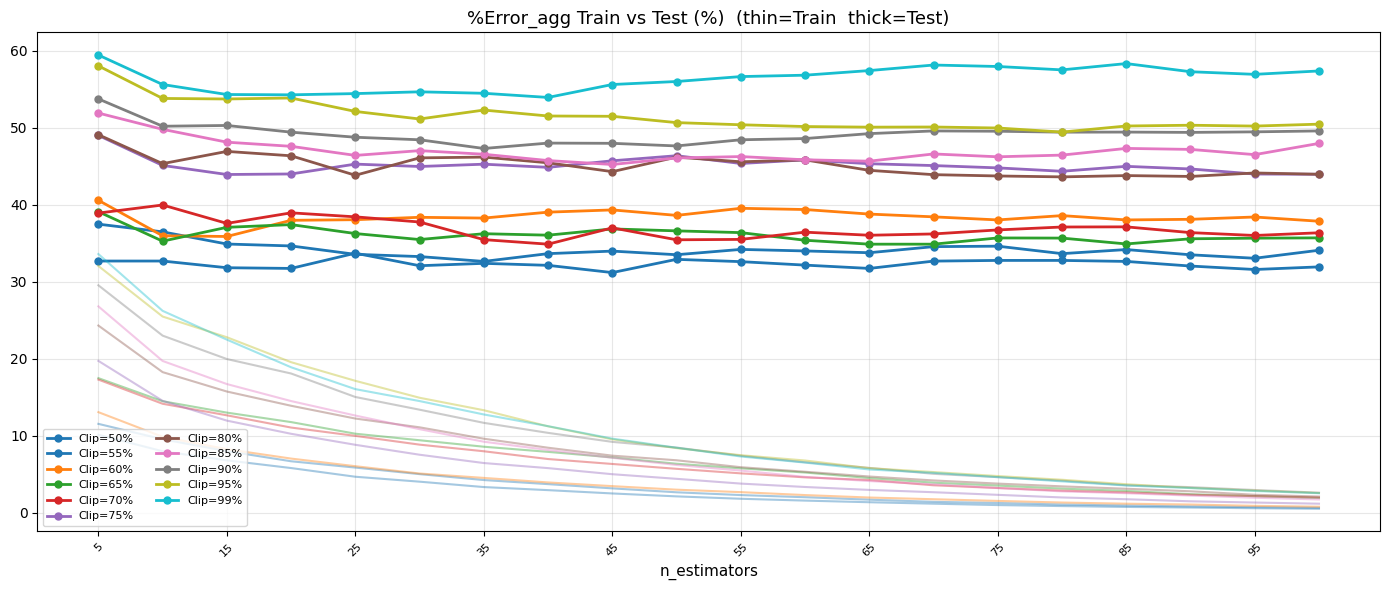

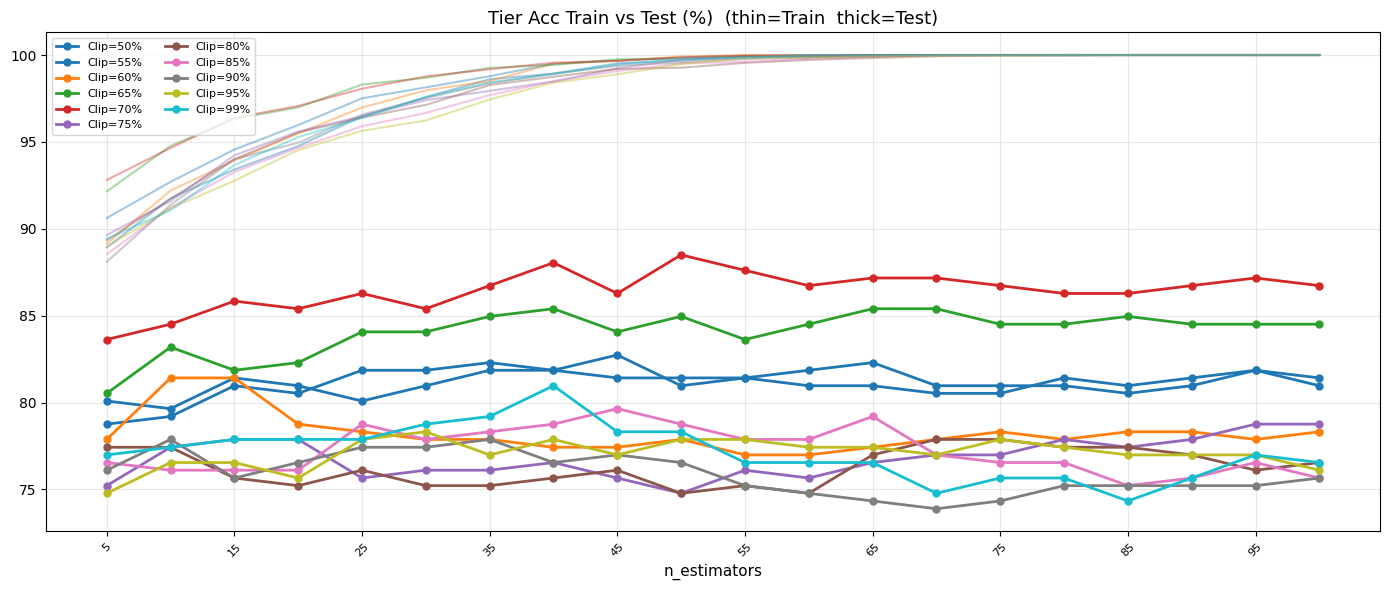

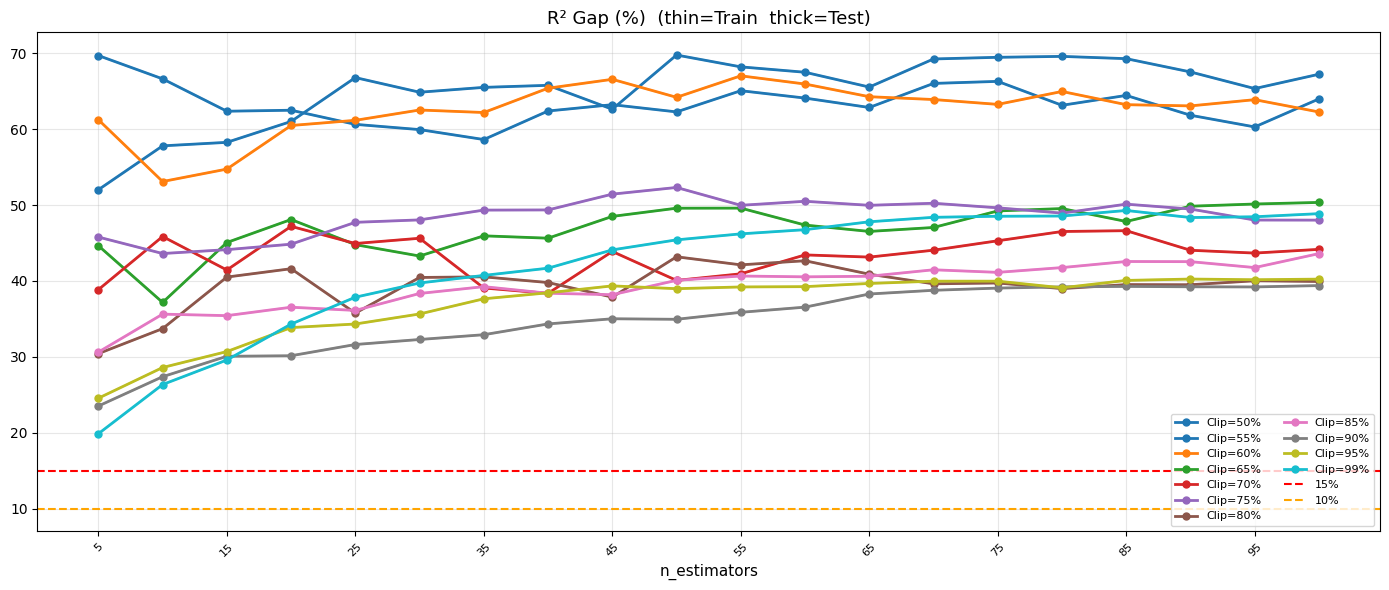


=== Summary at n=50 ===
  Clip    Thr    R2_Tr    R2_Te   R2_Gap   COV_Tr   COV_Te   Err_Tr   Err_Te
---------------------------------------------------------------------------
    50    325    98.67    28.92    69.75     6.38    54.90     2.65    32.91
    55    225    99.62    37.36    62.26     3.73    54.32     2.12    33.51
    60    200    99.53    35.35    64.18     4.52    58.57     2.99    38.62
    65    625    96.45    46.87    49.58    13.44    56.62     6.36    36.61
    70    725    97.73    57.66    40.07    11.71    54.14     5.70    35.45
    75    200    99.25    46.94    52.31     7.14    63.52     4.40    46.37
    80    150    98.14    54.95    43.18    12.01    62.12     6.81    46.19
    85    175    98.59    58.51    40.08    11.20    63.45     6.20    46.08
    90    150    97.51    62.56    34.95    15.81    63.90     8.46    47.64
    95    150    97.67    58.69    38.98    16.55    73.15     8.39    50.67
    99    175    97.56    52.15    45.41    18.73   

In [8]:
# =========================================================
# Cell 2-C: Learning Curve: Train + Test
# Best threshold per clip, n_estimators 5~100 (5 step)
# =========================================================

best_thr_by_clip = {
    50: 325,
    55: 225,
    60: 200,
    65: 625,
    70: 725,
    75: 200,
    80: 150,
    85: 175,
    90: 150,
    95: 150,
    99: 175,
}

n_estimators_list = list(range(5, 105, 5))
lc_results = {}

for cp in clip_percentiles:

    thr = best_thr_by_clip[cp]
    print(f"\n{'='*60}")
    print(f"Clip={cp}%  thr={thr}")
    print(f"{'='*60}")

    X_train_pos  = clf_results[cp]["X_train_pos"]
    X_test_pos   = clf_results[cp]["X_test_pos"]
    bldg_cols    = clf_results[cp]["bldg_cols"]
    occtype_cols = clf_results[cp]["occtype_cols"]
    grouped_cols = clf_results[cp]["grouped_cols"]

    y_reg_cp = clip_results[cp]["y_reg"]
    y_tr_pos = y_reg_cp.loc[X_train_pos.index]
    y_te_pos = y_reg_cp.loc[X_test_pos.index]

    low_mask_tr  = y_tr_pos <= thr
    high_mask_tr = y_tr_pos >  thr

    # Regression Feature Importance
    reg_feat_tmp = XGBRegressor(
        n_estimators=50, max_depth=6, min_child_weight=1,
        colsample_bynode=0.8, random_state=42, n_jobs=-1
    )
    reg_feat_tmp.fit(X_train_pos, np.log1p(y_tr_pos))

    fi_reg_raw = pd.DataFrame({
        "Feature":    X_train_pos.columns,
        "Importance": reg_feat_tmp.feature_importances_
    }).sort_values("Importance", ascending=False)

    grouped_imp_reg = {}
    grouped_imp_reg["bldg_type"] = fi_reg_raw[fi_reg_raw["Feature"].isin(bldg_cols)]["Importance"].sum()
    grouped_imp_reg["occtype"]   = fi_reg_raw[fi_reg_raw["Feature"].isin(occtype_cols)]["Importance"].sum()
    for _, row in fi_reg_raw.iterrows():
        if row["Feature"] not in grouped_cols:
            grouped_imp_reg[row["Feature"]] = row["Importance"]

    grouped_imp_reg_df = pd.DataFrame(
        grouped_imp_reg.items(), columns=["feature", "importance"]
    ).sort_values("importance", ascending=False).reset_index(drop=True)

    top20_reg_groups = grouped_imp_reg_df.head(20)["feature"].tolist()
    top20_reg        = expand_features(top20_reg_groups, bldg_cols, occtype_cols)

    # Tier Classifier SMOTE
    tier_label_tr = pd.Series(
        np.where(y_tr_pos <= thr, 0, 1),
        index=y_tr_pos.index
    )
    try:
        smote_l2 = SMOTE(random_state=42)
        X_sm_l2, y_sm_l2 = smote_l2.fit_resample(
            X_train_pos[top20_reg], tier_label_tr
        )
    except Exception:
        X_sm_l2 = X_train_pos[top20_reg]
        y_sm_l2 = tier_label_tr

    clip_lc = []

    for n in n_estimators_list:
        params = dict(
            n_estimators     = n,
            max_depth        = 6,
            min_child_weight = 1,
            colsample_bynode = 0.8,
            random_state     = 42,
            n_jobs           = -1
        )

        # Tier Classifier
        clf = XGBClassifier(**params)
        clf.fit(X_sm_l2, y_sm_l2)
        train_tier_acc = (clf.predict(X_sm_l2) == y_sm_l2).mean()
        tier_pred      = clf.predict(X_test_pos[top20_reg])
        tier_true      = np.where(y_te_pos <= thr, 0, 1)
        test_tier_acc  = (tier_pred == tier_true).mean()

        low_pred_te  = tier_pred == 0
        high_pred_te = tier_pred == 1

        # Regressor Low
        reg_l = XGBRegressor(**params)
        reg_l.fit(X_train_pos[top20_reg][low_mask_tr], np.log1p(y_tr_pos[low_mask_tr]))
        train_pred_low  = np.expm1(reg_l.predict(X_train_pos[top20_reg][low_mask_tr]))
        r2_train_low    = r2_score(y_tr_pos[low_mask_tr], train_pred_low)

        # Regressor High
        reg_h = XGBRegressor(**params)
        reg_h.fit(X_train_pos[top20_reg][high_mask_tr], np.log1p(y_tr_pos[high_mask_tr]))
        train_pred_high = np.expm1(reg_h.predict(X_train_pos[top20_reg][high_mask_tr]))
        r2_train_high   = r2_score(y_tr_pos[high_mask_tr], train_pred_high)

        # Overall Train
        y_pred_train = np.zeros(len(y_tr_pos))
        y_pred_train[low_mask_tr]  = train_pred_low
        y_pred_train[high_mask_tr] = train_pred_high
        y_pred_train = np.clip(y_pred_train, 0, None)

        # Overall Test
        y_pred_test = np.zeros(len(y_te_pos))
        if low_pred_te.sum() > 0:
            y_pred_test[low_pred_te]  = np.expm1(reg_l.predict(X_test_pos[top20_reg][low_pred_te]))
        if high_pred_te.sum() > 0:
            y_pred_test[high_pred_te] = np.expm1(reg_h.predict(X_test_pos[top20_reg][high_pred_te]))
        y_pred_test = np.clip(y_pred_test, 0, None)

        rmse_tr, _, r2_tr, nrmse_tr, cov_tr, agg_tr = calc_metrics(y_tr_pos.values, y_pred_train)
        rmse_te, _, r2_te, nrmse_te, cov_te, agg_te = calc_metrics(y_te_pos.values, y_pred_test)

        clip_lc.append({
            "n_estimators":   n,
            "Tier_Train(%)":  round(train_tier_acc * 100, 2),
            "Tier_Test(%)":   round(test_tier_acc  * 100, 2),
            "Tier_Gap(%)":    round((train_tier_acc - test_tier_acc) * 100, 2),
            "R2_Train(%)":    round(r2_tr   * 100, 2),
            "R2_Test(%)":     round(r2_te   * 100, 2),
            "R2_Gap(%)":      round((r2_tr - r2_te) * 100, 2),
            "NRMSE_Train(%)": round(nrmse_tr, 2),
            "NRMSE_Test(%)":  round(nrmse_te, 2),
            "COV_Train(%)":   round(cov_tr  * 100, 2),
            "COV_Test(%)":    round(cov_te  * 100, 2),
            "Err_Train(%)":   round(agg_tr, 2),
            "Err_Test(%)":    round(agg_te, 2),
        })

        print(f"n={n:4d}  "
              f"R2_Tr={r2_tr*100:.2f}%  R2_Te={r2_te*100:.2f}%  "
              f"COV_Tr={cov_tr*100:.2f}%  COV_Te={cov_te*100:.2f}%  "
              f"Err_Tr={agg_tr:.2f}%  Err_Te={agg_te:.2f}%")

    lc_results[cp] = pd.DataFrame(clip_lc)

# =========================================================
# Plot: Train vs Test per clip
# Each metric in separate figure for clarity
# =========================================================
cmap   = plt.cm.tab10
colors = {cp: cmap(i / len(clip_percentiles)) for i, cp in enumerate(clip_percentiles)}

metrics_plot = [
    ("R2_Train(%)",    "R2_Test(%)",    "R² Train vs Test (%)"),
    ("NRMSE_Train(%)", "NRMSE_Test(%)", "NRMSE Train vs Test (%)"),
    ("COV_Train(%)",   "COV_Test(%)",   "COV Train vs Test (%)"),
    ("Err_Train(%)",   "Err_Test(%)",   "%Error_agg Train vs Test (%)"),
    ("Tier_Train(%)",  "Tier_Test(%)",  "Tier Acc Train vs Test (%)"),
    ("R2_Gap(%)",      None,            "R² Gap (%)"),
]

for tr_col, te_col, title in metrics_plot:

    fig, ax = plt.subplots(figsize=(14, 6))

    for cp in clip_percentiles:
        df = lc_results[cp]
        # Train: thin solid line
        ax.plot(df["n_estimators"], df[tr_col],
                "-", color=colors[cp], alpha=0.4, linewidth=1.5)
        # Test: thick line with markers
        if te_col:
            ax.plot(df["n_estimators"], df[te_col],
                    "o-", color=colors[cp], markersize=5, linewidth=2,
                    label=f"Clip={cp}%")
        else:
            ax.plot(df["n_estimators"], df[tr_col],
                    "o-", color=colors[cp], markersize=5, linewidth=2,
                    label=f"Clip={cp}%")

    if te_col is None:
        ax.axhline(15, color="red",    linestyle="--", lw=1.5, label="15%")
        ax.axhline(10, color="orange", linestyle="--", lw=1.5, label="10%")

    ax.set_title(f"{title}  (thin=Train  thick=Test)", fontsize=13)
    ax.set_xlabel("n_estimators", fontsize=11)
    ax.set_xticks(n_estimators_list[::2])
    ax.set_xticklabels(n_estimators_list[::2], rotation=45, fontsize=8)
    ax.legend(fontsize=8, ncol=2, loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================================================
# Summary: n=50 per clip
# =========================================================
print("\n=== Summary at n=50 ===")
print(f"{'Clip':>6} {'Thr':>6} {'R2_Tr':>8} {'R2_Te':>8} {'R2_Gap':>8} "
      f"{'COV_Tr':>8} {'COV_Te':>8} "
      f"{'Err_Tr':>8} {'Err_Te':>8}")
print("-" * 75)

for cp in clip_percentiles:
    df  = lc_results[cp]
    row = df[df["n_estimators"] == 50].iloc[0]
    print(f"{cp:>6} {best_thr_by_clip[cp]:>6} "
          f"{row['R2_Train(%)']:>8.2f} {row['R2_Test(%)']:>8.2f} "
          f"{row['R2_Gap(%)']:>8.2f} "
          f"{row['COV_Train(%)']:>8.2f} {row['COV_Test(%)']:>8.2f} "
          f"{row['Err_Train(%)']:>8.2f} {row['Err_Test(%)']:>8.2f}")

Total combinations: 30
depth=    5  min_child_weight= 1  R2_Tr=93.18%  R2_Te=62.87%  Gap=30.31%  NRMSE_Te=21.03%  COV_Te=63.63%  Err_Te=47.24%
depth=    5  min_child_weight= 2  R2_Tr=93.26%  R2_Te=60.80%  Gap=32.45%  NRMSE_Te=21.61%  COV_Te=65.38%  Err_Te=49.38%
depth=    5  min_child_weight= 3  R2_Tr=92.61%  R2_Te=61.19%  Gap=31.42%  NRMSE_Te=21.50%  COV_Te=65.06%  Err_Te=48.47%
depth=    5  min_child_weight= 5  R2_Tr=92.03%  R2_Te=61.76%  Gap=30.27%  NRMSE_Te=21.35%  COV_Te=64.58%  Err_Te=48.17%
depth=    5  min_child_weight=10  R2_Tr=89.99%  R2_Te=60.63%  Gap=29.36%  NRMSE_Te=21.66%  COV_Te=65.53%  Err_Te=48.71%
depth=    6  min_child_weight= 1  R2_Tr=96.99%  R2_Te=63.79%  Gap=33.20%  NRMSE_Te=20.77%  COV_Te=62.84%  Err_Te=46.86%
depth=    6  min_child_weight= 2  R2_Tr=96.71%  R2_Te=62.60%  Gap=34.11%  NRMSE_Te=21.11%  COV_Te=63.86%  Err_Te=46.65%
depth=    6  min_child_weight= 3  R2_Tr=96.87%  R2_Te=58.56%  Gap=38.31%  NRMSE_Te=22.22%  COV_Te=67.23%  Err_Te=49.72%
depth=    6  min_

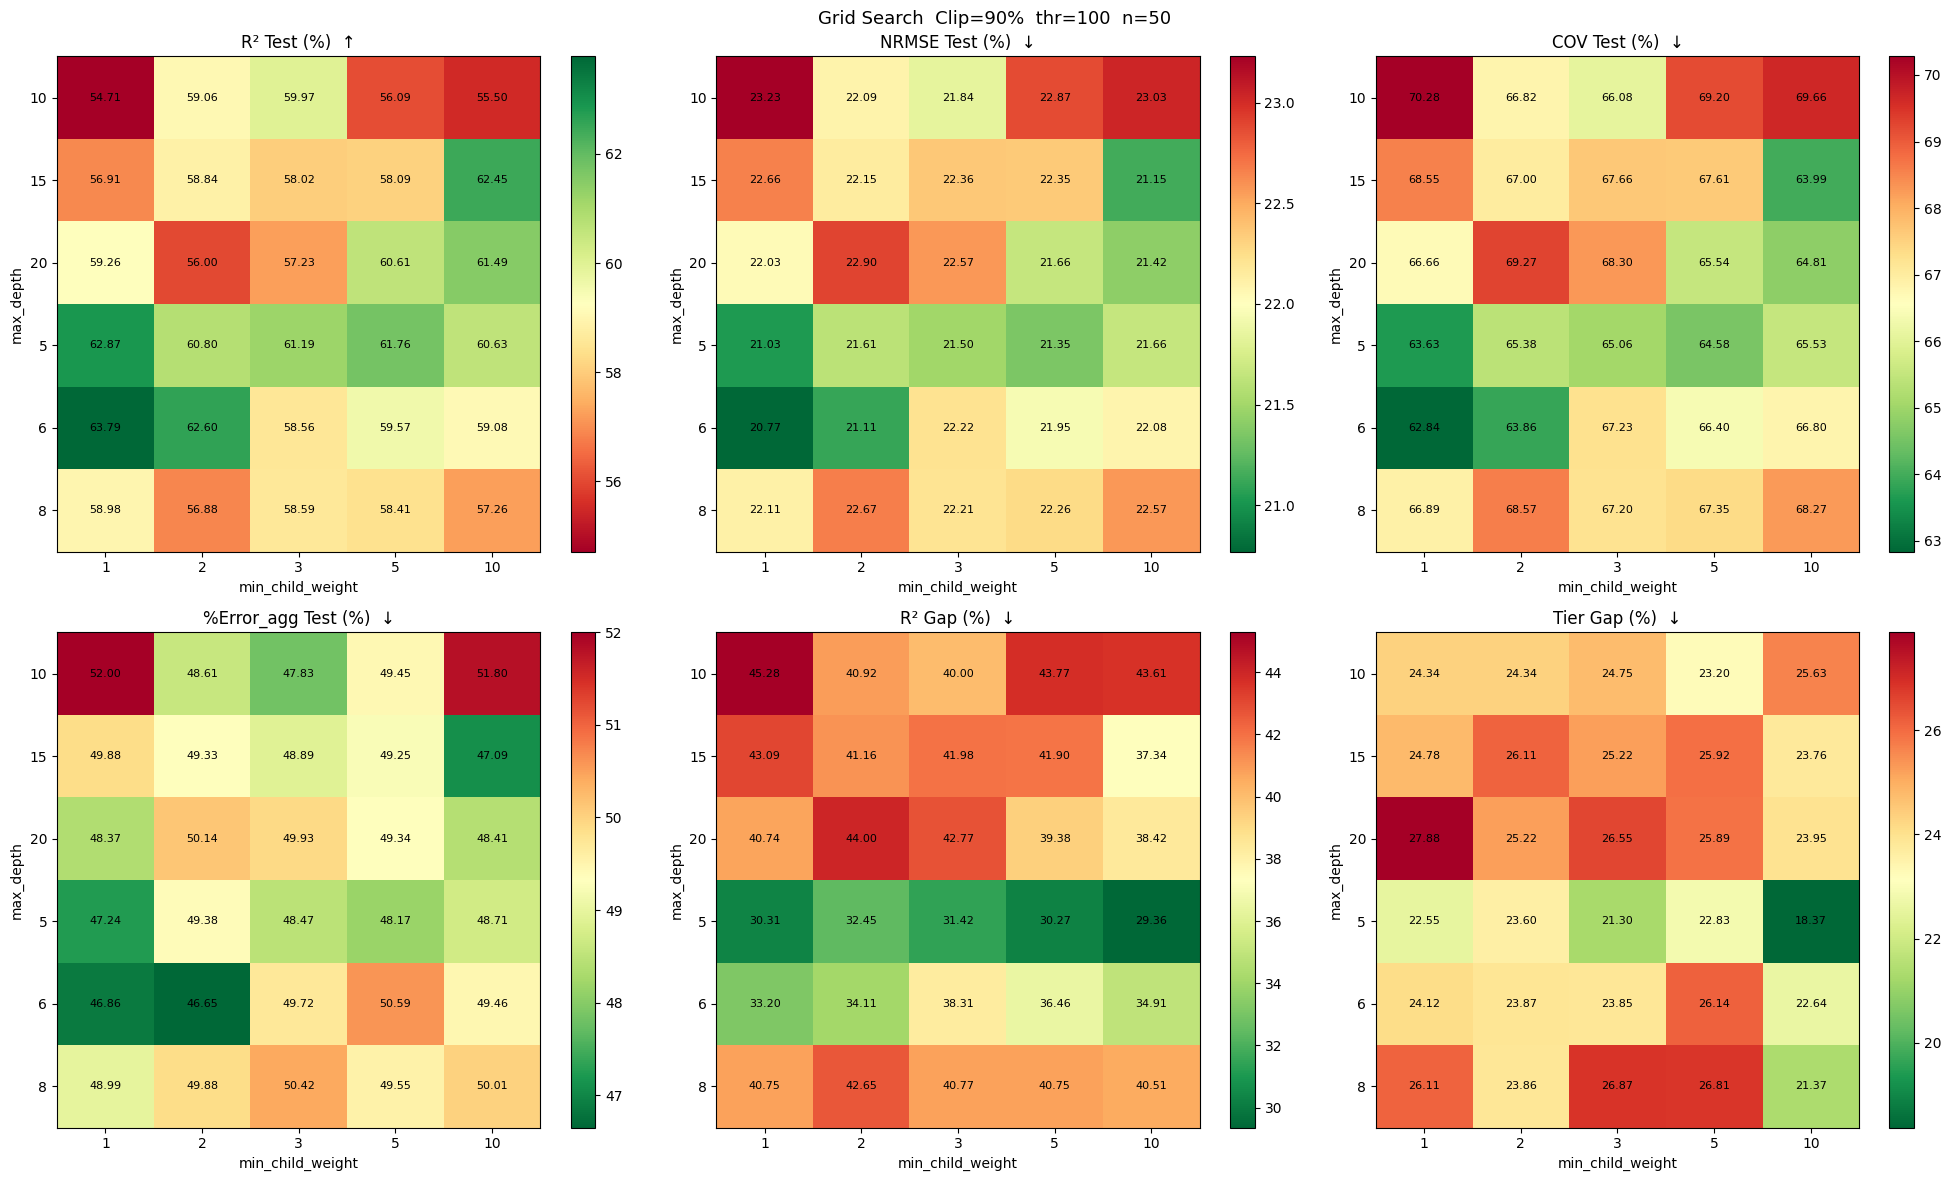


=== Top 10 (NRMSE_Test 기준) ===
max_depth  min_child_weight  R2_Train  R2_Test  R2_Gap  NRMSE_Test  COV_Test  Err_Test  Tier_Gap
        6                 1     96.99    63.79   33.20       20.77     62.84     46.86     24.12
        5                 1     93.18    62.87   30.31       21.03     63.63     47.24     22.55
        6                 2     96.71    62.60   34.11       21.11     63.86     46.65     23.87
       15                10     99.79    62.45   37.34       21.15     63.99     47.09     23.76
        5                 5     92.03    61.76   30.27       21.35     64.58     48.17     22.83
       20                10     99.91    61.49   38.42       21.42     64.81     48.41     23.95
        5                 3     92.61    61.19   31.42       21.50     65.06     48.47     21.30
        5                 2     93.26    60.80   32.45       21.61     65.38     49.38     23.60
        5                10     89.99    60.63   29.36       21.66     65.53     48.71     18.3

In [9]:
# =========================================================
# Grid Search: max_depth × min_child_weight
# Clip=90%, thr=100, n=50 
# =========================================================

from itertools import product

cp  = 90
thr = 100

X_train_pos  = clf_results[cp]["X_train_pos"]
X_test_pos   = clf_results[cp]["X_test_pos"]
bldg_cols    = clf_results[cp]["bldg_cols"]
occtype_cols = clf_results[cp]["occtype_cols"]
grouped_cols = clf_results[cp]["grouped_cols"]

y_reg_cp = clip_results[cp]["y_reg"]
y_tr_pos = y_reg_cp.loc[X_train_pos.index]
y_te_pos = y_reg_cp.loc[X_test_pos.index]

low_mask_tr  = y_tr_pos <= thr
high_mask_tr = y_tr_pos >  thr

# Feature Importance
reg_feat_tmp = XGBRegressor(
    n_estimators=50, max_depth=6, min_child_weight=1,
    colsample_bynode=0.8, random_state=42, n_jobs=-1
)
reg_feat_tmp.fit(X_train_pos, np.log1p(y_tr_pos))

fi_reg_raw = pd.DataFrame({
    "Feature":    X_train_pos.columns,
    "Importance": reg_feat_tmp.feature_importances_
}).sort_values("Importance", ascending=False)

grouped_imp_reg = {}
grouped_imp_reg["bldg_type"] = fi_reg_raw[fi_reg_raw["Feature"].isin(bldg_cols)]["Importance"].sum()
grouped_imp_reg["occtype"]   = fi_reg_raw[fi_reg_raw["Feature"].isin(occtype_cols)]["Importance"].sum()
for _, row in fi_reg_raw.iterrows():
    if row["Feature"] not in grouped_cols:
        grouped_imp_reg[row["Feature"]] = row["Importance"]

grouped_imp_reg_df = pd.DataFrame(
    grouped_imp_reg.items(), columns=["feature", "importance"]
).sort_values("importance", ascending=False).reset_index(drop=True)

top20_reg_groups = grouped_imp_reg_df.head(20)["feature"].tolist()
top20_reg        = expand_features(top20_reg_groups, bldg_cols, occtype_cols)

# Tier Classifier SMOTE
tier_label_tr = pd.Series(
    np.where(y_tr_pos <= thr, 0, 1),
    index=y_tr_pos.index
)
try:
    smote_l2 = SMOTE(random_state=42)
    X_sm_l2, y_sm_l2 = smote_l2.fit_resample(
        X_train_pos[top20_reg], tier_label_tr
    )
except Exception:
    X_sm_l2 = X_train_pos[top20_reg]
    y_sm_l2 = tier_label_tr

# Grid Search 파라미터
param_grid = {
    "max_depth"        : [5, 6, 8, 10, 15, 20],
    "min_child_weight" : [1, 2, 3, 5, 10],
}

combinations = list(product(
    param_grid["max_depth"],
    param_grid["min_child_weight"]
))
print(f"Total combinations: {len(combinations)}")

gs_results = []

for max_depth, min_child_weight in combinations:

    params = dict(
        n_estimators     = 50,
        max_depth        = max_depth,
        min_child_weight = min_child_weight,
        colsample_bynode = 0.8,
        random_state     = 42,
        n_jobs           = -1
    )

    # Tier Classifier
    clf = XGBClassifier(**params)
    clf.fit(X_sm_l2, y_sm_l2)
    train_tier_acc = (clf.predict(X_sm_l2) == y_sm_l2).mean()
    tier_pred      = clf.predict(X_test_pos[top20_reg])
    tier_true      = np.where(y_te_pos <= thr, 0, 1)
    test_tier_acc  = (tier_pred == tier_true).mean()

    low_pred_te  = tier_pred == 0
    high_pred_te = tier_pred == 1

    # Regressor Low
    reg_l = XGBRegressor(**params)
    reg_l.fit(X_train_pos[top20_reg][low_mask_tr], np.log1p(y_tr_pos[low_mask_tr]))
    train_pred_low  = np.expm1(reg_l.predict(X_train_pos[top20_reg][low_mask_tr]))
    r2_train_low    = r2_score(y_tr_pos[low_mask_tr], train_pred_low)

    # Regressor High
    reg_h = XGBRegressor(**params)
    reg_h.fit(X_train_pos[top20_reg][high_mask_tr], np.log1p(y_tr_pos[high_mask_tr]))
    train_pred_high = np.expm1(reg_h.predict(X_train_pos[top20_reg][high_mask_tr]))
    r2_train_high   = r2_score(y_tr_pos[high_mask_tr], train_pred_high)

    # Overall Train
    y_pred_train = np.zeros(len(y_tr_pos))
    y_pred_train[low_mask_tr]  = train_pred_low
    y_pred_train[high_mask_tr] = train_pred_high
    y_pred_train = np.clip(y_pred_train, 0, None)

    # Overall Test
    y_pred_test = np.zeros(len(y_te_pos))
    if low_pred_te.sum() > 0:
        y_pred_test[low_pred_te]  = np.expm1(reg_l.predict(X_test_pos[top20_reg][low_pred_te]))
    if high_pred_te.sum() > 0:
        y_pred_test[high_pred_te] = np.expm1(reg_h.predict(X_test_pos[top20_reg][high_pred_te]))
    y_pred_test = np.clip(y_pred_test, 0, None)

    rmse_tr, _, r2_tr, nrmse_tr, cov_tr, agg_tr = calc_metrics(y_tr_pos.values, y_pred_train)
    rmse_te, _, r2_te, nrmse_te, cov_te, agg_te = calc_metrics(y_te_pos.values, y_pred_test)

    gs_results.append({
        "max_depth":        str(max_depth),
        "min_child_weight": min_child_weight,
        "R2_Train":         round(r2_tr   * 100, 2),
        "R2_Test":          round(r2_te   * 100, 2),
        "R2_Gap":           round((r2_tr - r2_te) * 100, 2),
        "NRMSE_Train":      round(nrmse_tr, 2),
        "NRMSE_Test":       round(nrmse_te, 2),
        "COV_Train":        round(cov_tr  * 100, 2),
        "COV_Test":         round(cov_te  * 100, 2),
        "Err_Train":        round(agg_tr, 2),
        "Err_Test":         round(agg_te, 2),
        "Tier_Train":       round(train_tier_acc * 100, 2),
        "Tier_Test":        round(test_tier_acc  * 100, 2),
        "Tier_Gap":         round((train_tier_acc - test_tier_acc) * 100, 2),
    })

    print(f"depth={str(max_depth):>5}  min_child_weight={min_child_weight:>2}  "
          f"R2_Tr={r2_tr*100:.2f}%  R2_Te={r2_te*100:.2f}%  Gap={( r2_tr-r2_te)*100:.2f}%  "
          f"NRMSE_Te={nrmse_te:.2f}%  COV_Te={cov_te*100:.2f}%  Err_Te={agg_te:.2f}%")

gs_df = pd.DataFrame(gs_results)

# =========================================================
# 시각화: Heatmap (min_child_weight × max_depth)
# =========================================================
metrics_hm = [
    ("R2_Test",    "RdYlGn",   "R² Test (%)  ↑"),
    ("NRMSE_Test", "RdYlGn_r", "NRMSE Test (%)  ↓"),
    ("COV_Test",   "RdYlGn_r", "COV Test (%)  ↓"),
    ("Err_Test",   "RdYlGn_r", "%Error_agg Test (%)  ↓"),
    ("R2_Gap",     "RdYlGn_r", "R² Gap (%)  ↓"),
    ("Tier_Gap",   "RdYlGn_r", "Tier Gap (%)  ↓"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for ax, (metric, cmap, title) in zip(axes.flatten(), metrics_hm):
    pivot = gs_df.pivot(index="max_depth", columns="min_child_weight", values=metric)
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("min_child_weight")
    ax.set_ylabel("max_depth")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i,j]:.2f}",
                    ha="center", va="center", fontsize=8)

plt.suptitle(f"Grid Search  Clip={cp}%  thr={thr}  n=50", fontsize=13)
plt.tight_layout()
plt.show()

# =========================================================
# Summary
# =========================================================
print("\n=== Top 10 (NRMSE_Test 기준) ===")
print(gs_df.sort_values("NRMSE_Test")[
    ["max_depth", "min_child_weight", "R2_Train", "R2_Test",
     "R2_Gap", "NRMSE_Test", "COV_Test", "Err_Test", "Tier_Gap"]
].head(10).to_string(index=False))

print("\n=== Top 10 (COV_Test 기준) ===")
print(gs_df.sort_values("COV_Test")[
    ["max_depth", "min_child_weight", "R2_Train", "R2_Test",
     "R2_Gap", "NRMSE_Test", "COV_Test", "Err_Test", "Tier_Gap"]
].head(10).to_string(index=False))

print("\n=== Top 10 (%Error_agg 기준) ===")
print(gs_df.sort_values("Err_Test")[
    ["max_depth", "min_child_weight", "R2_Train", "R2_Test",
     "R2_Gap", "NRMSE_Test", "COV_Test", "Err_Test", "Tier_Gap"]
].head(10).to_string(index=False))

In [14]:
# =========================================================
# calc_metrics 업데이트
# =========================================================

def calc_metrics(y_true, y_pred):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = np.mean(np.abs(y_true - y_pred))
    r2    = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min()) * 100
    cov   = rmse / y_true.mean()
    agg   = np.abs(y_true - y_pred).sum() / y_true.sum() * 100

    # ARE (y_true > 1 인 샘플만)
    mask  = y_true > 1.0
    if mask.sum() > 0:
        are = np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    else:
        are = np.nan

    # cc (Pearson Correlation Coefficient)
    mu_pred = np.mean(y_pred)
    mu_true = np.mean(y_true)
    cc = (
        np.sum((y_pred - mu_pred) * (y_true - mu_true)) /
        (np.sqrt(np.sum((y_pred - mu_pred)**2)) *
         np.sqrt(np.sum((y_true - mu_true)**2)) + 1e-9)
    )

    # MSA (y_true > 0 인 샘플만)
    mask_msa = (y_true > 0) & (y_pred > 0)
    if mask_msa.sum() > 0:
        ratio = y_pred[mask_msa] / y_true[mask_msa]
        msa   = 100 * (np.exp(np.median(np.abs(np.log(ratio)))) - 1)
    else:
        msa = np.nan

    return rmse, mae, r2, nrmse, cov, agg, are, cc, msa
# =========================================================
# clip별 Train + Test 전체 metrics
# Clip별 best threshold, n=50 고정
# =========================================================

best_thr_by_clip = {
    50: 100,
    55: 100,
    60: 100,
    65: 100,
    70: 100,
    75: 100,
    80: 100,
    85: 100,
    90: 100,
    95: 175,
    99: 150,
}

full_results = []

for cp in clip_percentiles:

    thr = best_thr_by_clip[cp]

    X_train_pos  = clf_results[cp]["X_train_pos"]
    X_test_pos   = clf_results[cp]["X_test_pos"]
    bldg_cols    = clf_results[cp]["bldg_cols"]
    occtype_cols = clf_results[cp]["occtype_cols"]
    grouped_cols = clf_results[cp]["grouped_cols"]

    y_reg_cp = clip_results[cp]["y_reg"]
    y_tr_pos = y_reg_cp.loc[X_train_pos.index]
    y_te_pos = y_reg_cp.loc[X_test_pos.index]

    low_mask_tr  = y_tr_pos <= thr
    high_mask_tr = y_tr_pos >  thr

    # Feature Importance
    reg_feat_tmp = XGBRegressor(
        n_estimators=50, max_depth=6, min_child_weight=1,
        colsample_bynode=0.8, random_state=42, n_jobs=-1
    )
    reg_feat_tmp.fit(X_train_pos, np.log1p(y_tr_pos))

    fi_reg_raw = pd.DataFrame({
        "Feature":    X_train_pos.columns,
        "Importance": reg_feat_tmp.feature_importances_
    }).sort_values("Importance", ascending=False)

    grouped_imp_reg = {}
    grouped_imp_reg["bldg_type"] = fi_reg_raw[fi_reg_raw["Feature"].isin(bldg_cols)]["Importance"].sum()
    grouped_imp_reg["occtype"]   = fi_reg_raw[fi_reg_raw["Feature"].isin(occtype_cols)]["Importance"].sum()
    for _, row in fi_reg_raw.iterrows():
        if row["Feature"] not in grouped_cols:
            grouped_imp_reg[row["Feature"]] = row["Importance"]

    grouped_imp_reg_df = pd.DataFrame(
        grouped_imp_reg.items(), columns=["feature", "importance"]
    ).sort_values("importance", ascending=False).reset_index(drop=True)

    top20_reg_groups = grouped_imp_reg_df.head(20)["feature"].tolist()
    top20_reg        = expand_features(top20_reg_groups, bldg_cols, occtype_cols)

    # Tier Classifier
    tier_label_tr = pd.Series(
        np.where(y_tr_pos <= thr, 0, 1),
        index=y_tr_pos.index
    )
    try:
        smote_l2 = SMOTE(random_state=42)
        X_sm_l2, y_sm_l2 = smote_l2.fit_resample(
            X_train_pos[top20_reg], tier_label_tr
        )
    except Exception:
        X_sm_l2 = X_train_pos[top20_reg]
        y_sm_l2 = tier_label_tr

    params = dict(
        n_estimators     = 50,
        max_depth        = 6,
        min_child_weight = 1,
        colsample_bynode = 0.8,
        random_state     = 42,
        n_jobs           = -1
    )

    clf = XGBClassifier(**params)
    clf.fit(X_sm_l2, y_sm_l2)
    train_tier_acc = (clf.predict(X_sm_l2) == y_sm_l2).mean()
    tier_pred      = clf.predict(X_test_pos[top20_reg])
    tier_true      = np.where(y_te_pos <= thr, 0, 1)
    test_tier_acc  = (tier_pred == tier_true).mean()

    low_pred_te  = tier_pred == 0
    high_pred_te = tier_pred == 1

    # Regressor
    reg_l = XGBRegressor(**params)
    reg_l.fit(X_train_pos[top20_reg][low_mask_tr], np.log1p(y_tr_pos[low_mask_tr]))

    reg_h = XGBRegressor(**params)
    reg_h.fit(X_train_pos[top20_reg][high_mask_tr], np.log1p(y_tr_pos[high_mask_tr]))

    # Train 예측
    y_pred_train = np.zeros(len(y_tr_pos))
    y_pred_train[low_mask_tr]  = np.expm1(reg_l.predict(X_train_pos[top20_reg][low_mask_tr]))
    y_pred_train[high_mask_tr] = np.expm1(reg_h.predict(X_train_pos[top20_reg][high_mask_tr]))
    y_pred_train = np.clip(y_pred_train, 0, None)

    # Test 예측
    y_pred_test = np.zeros(len(y_te_pos))
    if low_pred_te.sum() > 0:
        y_pred_test[low_pred_te]  = np.expm1(reg_l.predict(X_test_pos[top20_reg][low_pred_te]))
    if high_pred_te.sum() > 0:
        y_pred_test[high_pred_te] = np.expm1(reg_h.predict(X_test_pos[top20_reg][high_pred_te]))
    y_pred_test = np.clip(y_pred_test, 0, None)

    rmse_tr, mae_tr, r2_tr, nrmse_tr, cov_tr, agg_tr, are_tr, cc_tr, msa_tr = calc_metrics(y_tr_pos.values, y_pred_train)
    rmse_te, mae_te, r2_te, nrmse_te, cov_te, agg_te, are_te, cc_te, msa_te = calc_metrics(y_te_pos.values, y_pred_test)

    full_results.append({
        "Clip":         cp,
        "Threshold":    thr,
        # Train
        "R2_Tr":        round(r2_tr   * 100, 2),
        "RMSE_Tr":      round(rmse_tr,        2),
        "MAE_Tr":       round(mae_tr,         2),
        "NRMSE_Tr":     round(nrmse_tr,       2),
        "COV_Tr":       round(cov_tr  * 100,  2),
        "Err_Tr":       round(agg_tr,         2),
        "ARE_Tr":       round(are_tr,         2),
        "cc_Tr":        round(cc_tr,          4),
        "MSA_Tr":       round(msa_tr,         2),
        # Test
        "R2_Te":        round(r2_te   * 100,  2),
        "RMSE_Te":      round(rmse_te,        2),
        "MAE_Te":       round(mae_te,         2),
        "NRMSE_Te":     round(nrmse_te,       2),
        "COV_Te":       round(cov_te  * 100,  2),
        "Err_Te":       round(agg_te,         2),
        "ARE_Te":       round(are_te,         2),
        "cc_Te":        round(cc_te,          4),
        "MSA_Te":       round(msa_te,         2),
        # Gap
        "R2_Gap":       round((r2_tr - r2_te) * 100, 2),
        "Tier_Tr":      round(train_tier_acc * 100, 2),
        "Tier_Te":      round(test_tier_acc  * 100, 2),
        "Tier_Gap":     round((train_tier_acc - test_tier_acc) * 100, 2),
    })

    print(f"\nClip={cp}%  thr={thr}")
    print(f"  {'':10} {'Train':>10} {'Test':>10}")
    print(f"  {'R²(%)':10} {r2_tr*100:>10.2f} {r2_te*100:>10.2f}")
    print(f"  {'RMSE':10} {rmse_tr:>10.2f} {rmse_te:>10.2f}")
    print(f"  {'MAE':10} {mae_tr:>10.2f} {mae_te:>10.2f}")
    print(f"  {'NRMSE(%)':10} {nrmse_tr:>10.2f} {nrmse_te:>10.2f}")
    print(f"  {'COV(%)':10} {cov_tr*100:>10.2f} {cov_te*100:>10.2f}")
    print(f"  {'%Error':10} {agg_tr:>10.2f} {agg_te:>10.2f}")
    print(f"  {'ARE(%)':10} {are_tr:>10.2f} {are_te:>10.2f}")
    print(f"  {'cc':10} {cc_tr:>10.4f} {cc_te:>10.4f}")
    print(f"  {'MSA(%)':10} {msa_tr:>10.2f} {msa_te:>10.2f}")
    print(f"  {'Tier_Acc':10} {train_tier_acc*100:>10.2f} {test_tier_acc*100:>10.2f}")

full_df = pd.DataFrame(full_results)

# =========================================================
# Summary Table
# =========================================================
print("\n" + "="*110)
print("=== Clip별 Full Metrics Summary ===")
print("="*110)
print(f"{'Clip':>6} {'Thr':>5} "
      f"{'R2_Tr':>7} {'R2_Te':>7} {'R2_Gap':>7} "
      f"{'NRMSE_Tr':>9} {'NRMSE_Te':>9} "
      f"{'COV_Tr':>7} {'COV_Te':>7} "
      f"{'Err_Tr':>7} {'Err_Te':>7} "
      f"{'ARE_Tr':>7} {'ARE_Te':>7} "
      f"{'cc_Tr':>7} {'cc_Te':>7} "
      f"{'MSA_Tr':>7} {'MSA_Te':>7}")
print("-" * 130)
for _, row in full_df.iterrows():
    print(f"{int(row['Clip']):>6} {int(row['Threshold']):>5} "
          f"{row['R2_Tr']:>7.2f} {row['R2_Te']:>7.2f} {row['R2_Gap']:>7.2f} "
          f"{row['NRMSE_Tr']:>9.2f} {row['NRMSE_Te']:>9.2f} "
          f"{row['COV_Tr']:>7.2f} {row['COV_Te']:>7.2f} "
          f"{row['Err_Tr']:>7.2f} {row['Err_Te']:>7.2f} "
          f"{row['ARE_Tr']:>7.2f} {row['ARE_Te']:>7.2f} "
          f"{row['cc_Tr']:>7.4f} {row['cc_Te']:>7.4f} "
          f"{row['MSA_Tr']:>7.2f} {row['MSA_Te']:>7.2f}")


Clip=50%  thr=100
                  Train       Test
  R²(%)           99.05      27.38
  RMSE            12.17     119.06
  MAE              7.78      80.76
  NRMSE(%)         3.67      35.74
  COV(%)           5.40      55.49
  %Error           3.45      37.63
  ARE(%)           4.16      81.82
  cc             0.9955     0.5807
  MSA(%)           2.58      13.88
  Tier_Acc        99.66      74.78

Clip=55%  thr=100
                  Train       Test
  R²(%)           98.65      38.04
  RMSE            18.49     136.12
  MAE             11.30      94.25
  NRMSE(%)         4.49      32.95
  COV(%)           7.02      54.03
  %Error           4.29      37.41
  ARE(%)           4.74      88.59
  cc             0.9937     0.6498
  MSA(%)           2.88      16.76
  Tier_Acc        99.57      73.45

Clip=60%  thr=100
                  Train       Test
  R²(%)           98.41      40.72
  RMSE            25.37     164.64
  MAE             15.59     118.73
  NRMSE(%)         4.95      32.0

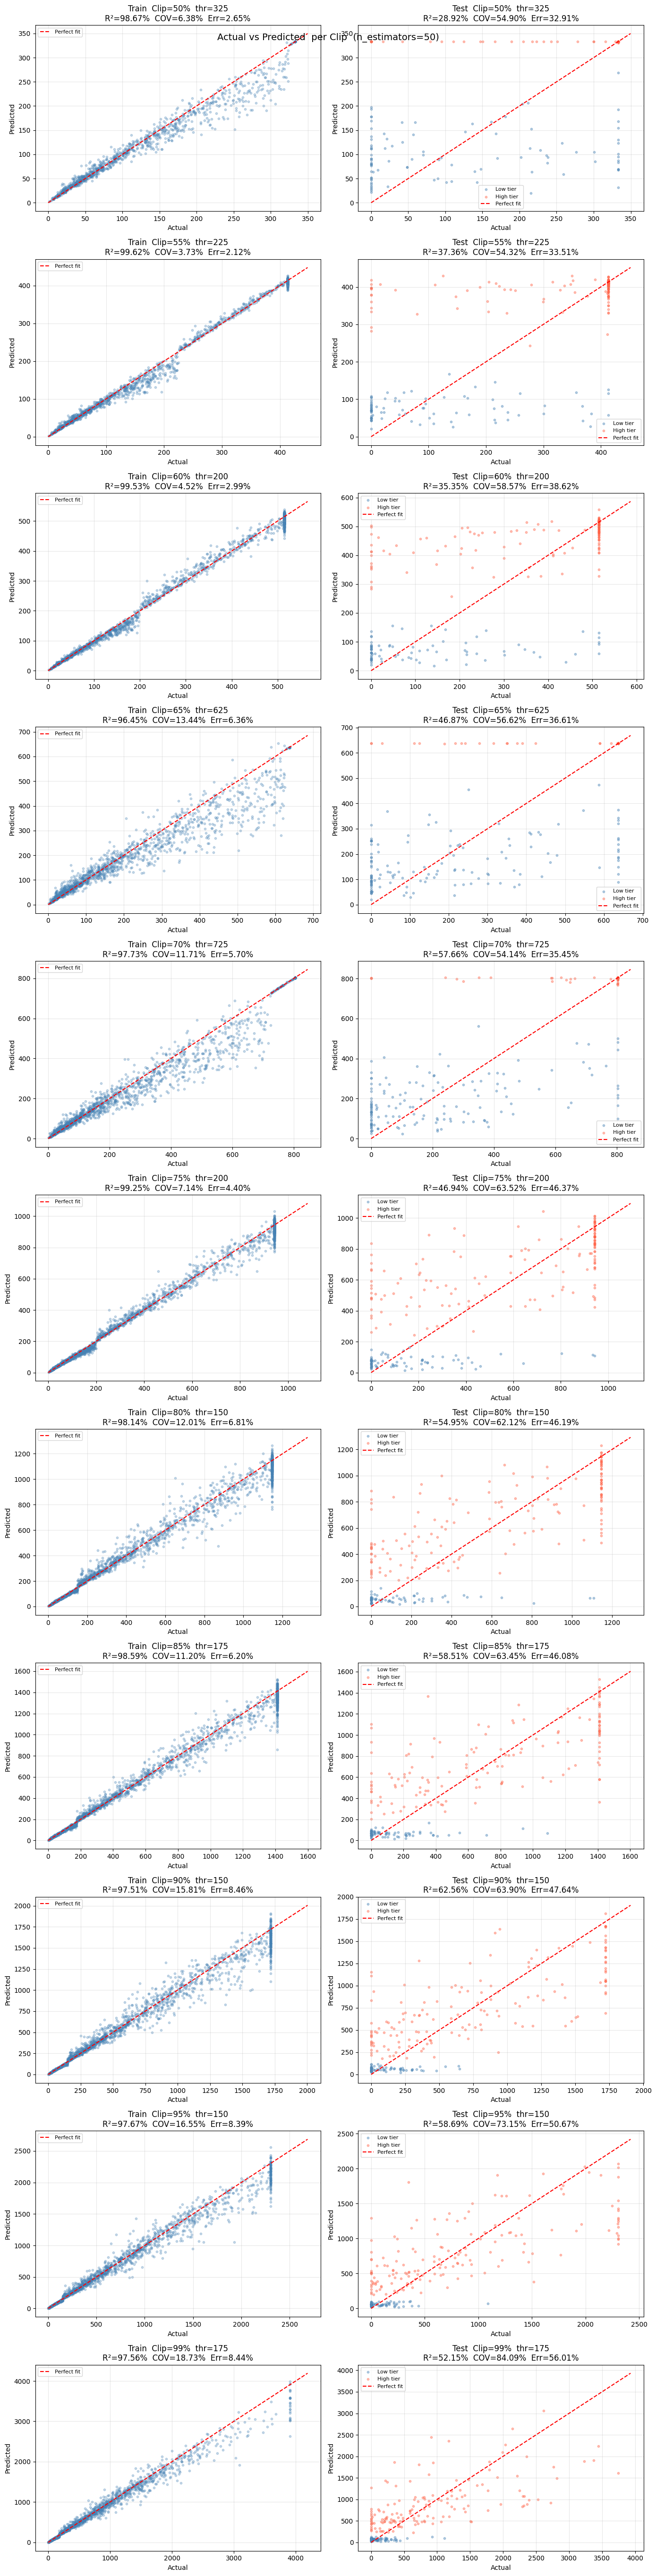


=== Actual vs Predicted Summary ===
  Clip    Thr    R2_Tr    R2_Te   COV_Tr   COV_Te   Err_Tr   Err_Te
----------------------------------------------------------------------
    50    325    98.67    28.92     6.38    54.90     2.65    32.91
    55    225    99.62    37.36     3.73    54.32     2.12    33.51
    60    200    99.53    35.35     4.52    58.57     2.99    38.62
    65    625    96.45    46.87    13.44    56.62     6.36    36.61
    70    725    97.73    57.66    11.71    54.14     5.70    35.45
    75    200    99.25    46.94     7.14    63.52     4.40    46.37
    80    150    98.14    54.95    12.01    62.12     6.81    46.19
    85    175    98.59    58.51    11.20    63.45     6.20    46.08
    90    150    97.51    62.56    15.81    63.90     8.46    47.64
    95    150    97.67    58.69    16.55    73.15     8.39    50.67
    99    175    97.56    52.15    18.73    84.09     8.44    56.01


In [16]:
# =========================================================
# Prediction vs Actual Scatter Plot
# Final model evaluation per clip
# =========================================================

# Use best threshold per clip (COV_Train based)
best_thr_by_clip = {
    50: 325,
    55: 225,
    60: 200,
    65: 625,
    70: 725,
    75: 200,
    80: 150,
    85: 175,
    90: 150,
    95: 150,
    99: 175,
}

n_estimators = 50  # fixed

scatter_results = {}

for cp in clip_percentiles:

    thr = best_thr_by_clip[cp]

    X_train_pos  = clf_results[cp]["X_train_pos"]
    X_test_pos   = clf_results[cp]["X_test_pos"]
    bldg_cols    = clf_results[cp]["bldg_cols"]
    occtype_cols = clf_results[cp]["occtype_cols"]
    grouped_cols = clf_results[cp]["grouped_cols"]

    y_reg_cp = clip_results[cp]["y_reg"]
    y_tr_pos = y_reg_cp.loc[X_train_pos.index]
    y_te_pos = y_reg_cp.loc[X_test_pos.index]

    low_mask_tr  = y_tr_pos <= thr
    high_mask_tr = y_tr_pos >  thr

    # Feature Importance
    reg_feat_tmp = XGBRegressor(
        n_estimators=n_estimators, max_depth=6,
        min_child_weight=1, colsample_bynode=0.8,
        random_state=42, n_jobs=-1
    )
    reg_feat_tmp.fit(X_train_pos, np.log1p(y_tr_pos))

    fi_reg_raw = pd.DataFrame({
        "Feature":    X_train_pos.columns,
        "Importance": reg_feat_tmp.feature_importances_
    }).sort_values("Importance", ascending=False)

    grouped_imp_reg = {}
    grouped_imp_reg["bldg_type"] = fi_reg_raw[fi_reg_raw["Feature"].isin(bldg_cols)]["Importance"].sum()
    grouped_imp_reg["occtype"]   = fi_reg_raw[fi_reg_raw["Feature"].isin(occtype_cols)]["Importance"].sum()
    for _, row in fi_reg_raw.iterrows():
        if row["Feature"] not in grouped_cols:
            grouped_imp_reg[row["Feature"]] = row["Importance"]

    grouped_imp_reg_df = pd.DataFrame(
        grouped_imp_reg.items(), columns=["feature", "importance"]
    ).sort_values("importance", ascending=False).reset_index(drop=True)

    top20_reg_groups = grouped_imp_reg_df.head(20)["feature"].tolist()
    top20_reg        = expand_features(top20_reg_groups, bldg_cols, occtype_cols)

    # Tier Classifier
    tier_label_tr = pd.Series(
        np.where(y_tr_pos <= thr, 0, 1),
        index=y_tr_pos.index
    )
    try:
        smote_l2 = SMOTE(random_state=42)
        X_sm_l2, y_sm_l2 = smote_l2.fit_resample(
            X_train_pos[top20_reg], tier_label_tr
        )
    except Exception:
        X_sm_l2 = X_train_pos[top20_reg]
        y_sm_l2 = tier_label_tr

    params = dict(
        n_estimators     = n_estimators,
        max_depth        = 6,
        min_child_weight = 1,
        colsample_bynode = 0.8,
        random_state     = 42,
        n_jobs           = -1
    )

    clf_tier = XGBClassifier(**params)
    clf_tier.fit(X_sm_l2, y_sm_l2)

    tier_pred    = clf_tier.predict(X_test_pos[top20_reg])
    low_pred_te  = tier_pred == 0
    high_pred_te = tier_pred == 1

    # Regressors
    reg_l = XGBRegressor(**params)
    reg_l.fit(X_train_pos[top20_reg][low_mask_tr], np.log1p(y_tr_pos[low_mask_tr]))

    reg_h = XGBRegressor(**params)
    reg_h.fit(X_train_pos[top20_reg][high_mask_tr], np.log1p(y_tr_pos[high_mask_tr]))

    # Train Prediction
    y_pred_train = np.zeros(len(y_tr_pos))
    y_pred_train[low_mask_tr]  = np.expm1(reg_l.predict(X_train_pos[top20_reg][low_mask_tr]))
    y_pred_train[high_mask_tr] = np.expm1(reg_h.predict(X_train_pos[top20_reg][high_mask_tr]))
    y_pred_train = np.clip(y_pred_train, 0, None)

    # Test Prediction
    y_pred_test = np.zeros(len(y_te_pos))
    if low_pred_te.sum() > 0:
        y_pred_test[low_pred_te]  = np.expm1(reg_l.predict(X_test_pos[top20_reg][low_pred_te]))
    if high_pred_te.sum() > 0:
        y_pred_test[high_pred_te] = np.expm1(reg_h.predict(X_test_pos[top20_reg][high_pred_te]))
    y_pred_test = np.clip(y_pred_test, 0, None)

    rmse_tr, _, r2_tr, nrmse_tr, cov_tr, agg_tr, _, _, _ = calc_metrics(y_tr_pos.values, y_pred_train)
    rmse_te, _, r2_te, nrmse_te, cov_te, agg_te, _, _, _ = calc_metrics(y_te_pos.values, y_pred_test)

    scatter_results[cp] = {
        "y_tr_pos":    y_tr_pos.values,
        "y_pred_train": y_pred_train,
        "y_te_pos":    y_te_pos.values,
        "y_pred_test": y_pred_test,
        "low_pred_te": low_pred_te,
        "high_pred_te":high_pred_te,
        "r2_tr": r2_tr, "nrmse_tr": nrmse_tr,
        "cov_tr": cov_tr, "agg_tr": agg_tr,
        "r2_te": r2_te, "nrmse_te": nrmse_te,
        "cov_te": cov_te, "agg_te": agg_te,
    }

# =========================================================
# Scatter Plot: Actual vs Predicted per Clip
# =========================================================
n_clips = len(clip_percentiles)
fig, axes = plt.subplots(n_clips, 2, figsize=(14, n_clips * 5))

for i, cp in enumerate(clip_percentiles):
    r = scatter_results[cp]

    # Train scatter
    ax = axes[i, 0]
    ax.scatter(r["y_tr_pos"], r["y_pred_train"],
               alpha=0.3, s=10, color="steelblue")
    lim = max(r["y_tr_pos"].max(), r["y_pred_train"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect fit")
    ax.set_title(
        f"Train  Clip={cp}%  thr={best_thr_by_clip[cp]}\n"
        f"R²={r['r2_tr']*100:.2f}%  COV={r['cov_tr']*100:.2f}%  "
        f"Err={r['agg_tr']:.2f}%"
    )
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Test scatter
    ax = axes[i, 1]
    ax.scatter(r["y_te_pos"][r["low_pred_te"]],
               r["y_pred_test"][r["low_pred_te"]],
               alpha=0.4, s=10, color="steelblue", label="Low tier")
    ax.scatter(r["y_te_pos"][r["high_pred_te"]],
               r["y_pred_test"][r["high_pred_te"]],
               alpha=0.4, s=10, color="tomato", label="High tier")
    lim = max(r["y_te_pos"].max(), r["y_pred_test"].max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", lw=1.5, label="Perfect fit")
    ax.set_title(
        f"Test  Clip={cp}%  thr={best_thr_by_clip[cp]}\n"
        f"R²={r['r2_te']*100:.2f}%  COV={r['cov_te']*100:.2f}%  "
        f"Err={r['agg_te']:.2f}%"
    )
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Actual vs Predicted  per Clip  (n_estimators=50)", fontsize=14)
plt.tight_layout()
plt.show()

# =========================================================
# Summary
# =========================================================
print("\n=== Actual vs Predicted Summary ===")
print(f"{'Clip':>6} {'Thr':>6} "
      f"{'R2_Tr':>8} {'R2_Te':>8} "
      f"{'COV_Tr':>8} {'COV_Te':>8} "
      f"{'Err_Tr':>8} {'Err_Te':>8}")
print("-" * 70)
for cp in clip_percentiles:
    r = scatter_results[cp]
    print(f"{cp:>6} {best_thr_by_clip[cp]:>6} "
          f"{r['r2_tr']*100:>8.2f} {r['r2_te']*100:>8.2f} "
          f"{r['cov_tr']*100:>8.2f} {r['cov_te']*100:>8.2f} "
          f"{r['agg_tr']:>8.2f} {r['agg_te']:>8.2f}")